# Sharren Elvaretta Pratamadya Fianto (244107020191)

# Langkah 1: Setup & Import

In [2]:
import time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, Normalizer, normalize
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score, pairwise_distances)

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

# Langkah 2: Load Dataset

In [3]:
from google.colab import files
import os

if not os.path.exists('lettuce_dataset_updated.csv'):
    files.upload()   # pilih lettuce_dataset_updated.csv

# encoding latin1 karena ada simbol derajat (°) pada nama kolom
df = pd.read_csv('lettuce_dataset_updated.csv', encoding='latin1')
df.columns = df.columns.str.strip()

print(f"Total data awal: {df.shape[0]} baris, {df.shape[1]} kolom")
print(f"Missing value total: {int(df.isna().sum().sum())}")
df.head()

Saving lettuce_dataset_updated.csv to lettuce_dataset_updated.csv
Total data awal: 3169 baris, 9 kolom
Missing value total: 0


,Plant_ID,Date,Temperature (°C),Humidity (%),TDS Value (ppm),pH Level,Growth Days,Temperature (F),Humidity
0,1,8/3/2023,33.4,53,582,6.4,1,92.12,0.53
1,1,8/4/2023,33.5,53,451,6.1,2,92.30,0.53
2,1,8/5/2023,33.4,59,678,6.4,3,92.12,0.59
3,1,8/6/2023,33.4,68,420,6.4,4,92.12,0.68
4,1,8/7/2023,33.4,74,637,6.5,5,92.12,0.74


# Langkah 3: Preprocessing + Fungsi Pembagian Data

In [4]:
features = ['Temperature (°C)', 'Humidity (%)', 'TDS Value (ppm)', 'pH Level', 'Growth Days']

# Imputasi median -> Standarisasi -> L2 Normalization
preprocess = make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), Normalizer())

SPLITS = {"Full Data (100%)": 1.0, "80% Data": 0.8, "50% Data": 0.5, "30% Data": 0.3}

def get_data_splits(data):
    return {name: preprocess.fit_transform(
                (data if frac == 1 else data.sample(frac=frac, random_state=RANDOM_STATE)).sort_index()[features])
            for name, frac in SPLITS.items()}

data_splits = get_data_splits(df)

for name, X in data_splits.items():
    print(f"{name:<18}: {X.shape[0]:>5} baris x {X.shape[1]} fitur")

Full Data (100%)  :  3169 baris x 5 fitur
80% Data          :  2535 baris x 5 fitur
50% Data          :  1584 baris x 5 fitur
30% Data          :   951 baris x 5 fitur


# Langkah 4: Cosine Distance (Spherical K-Means)

In [5]:
class KMeansCosine:
    """Assignment pakai Cosine Distance, centroid = rata-rata ter-normalisasi."""
    def __init__(self, n_clusters=3, max_iter=300, tol=1e-4, random_state=RANDOM_STATE):
        self.n_clusters, self.max_iter, self.tol, self.random_state = n_clusters, max_iter, tol, random_state

    def _dist(self, X, C):
        return pairwise_distances(X, C, metric='cosine')

    def fit(self, X):
        t0 = time.perf_counter()
        X, n = normalize(X), len(X)

        # Inisialisasi centroid ala k-means++ (jarak cosine)
        rng = np.random.RandomState(self.random_state)
        C = [X[rng.randint(n)]]
        for _ in range(self.n_clusters - 1):
            d = self._dist(X, np.array(C)).min(axis=1) ** 2
            C.append(X[rng.choice(n, p=np.ones(n) / n if d.sum() == 0 else d / d.sum())])
        self.centroids = normalize(np.array(C))

        rng = np.random.RandomState(self.random_state)  # dipakai jika ada klaster kosong
        for self.n_iter_ in range(1, self.max_iter + 1):
            labels = self._dist(X, self.centroids).argmin(axis=1)
            new_c = np.array([normalize(X[labels == k].mean(axis=0, keepdims=True))[0] if (labels == k).any()
                              else X[rng.randint(n)] for k in range(self.n_clusters)])
            shift = np.linalg.norm(new_c - self.centroids)
            self.centroids, self.labels_ = new_c, labels
            if shift <= self.tol:
                break

        self.inertia_ = self._dist(X, self.centroids)[np.arange(n), self.labels_].sum()
        self.execution_time_ = time.perf_counter() - t0
        return self

def find_elbow_point(k_vals, inertias):
    """Titik dengan jarak terjauh dari garis lurus (k_awal -> k_akhir)."""
    pts = np.column_stack([k_vals, inertias]).astype(float)
    u = (pts[-1] - pts[0]) / np.linalg.norm(pts[-1] - pts[0])
    v = pts - pts[0]
    return k_vals[np.argmax(np.linalg.norm(v - np.outer(v @ u, u), axis=1))]

# Langkah 5: Elbow Method

Full Data (100%)   -> k optimal = 4 (inertia = 1251.48)
80% Data           -> k optimal = 3 (inertia = 1184.78)
50% Data           -> k optimal = 3 (inertia = 727.19)
30% Data           -> k optimal = 3 (inertia = 434.39)


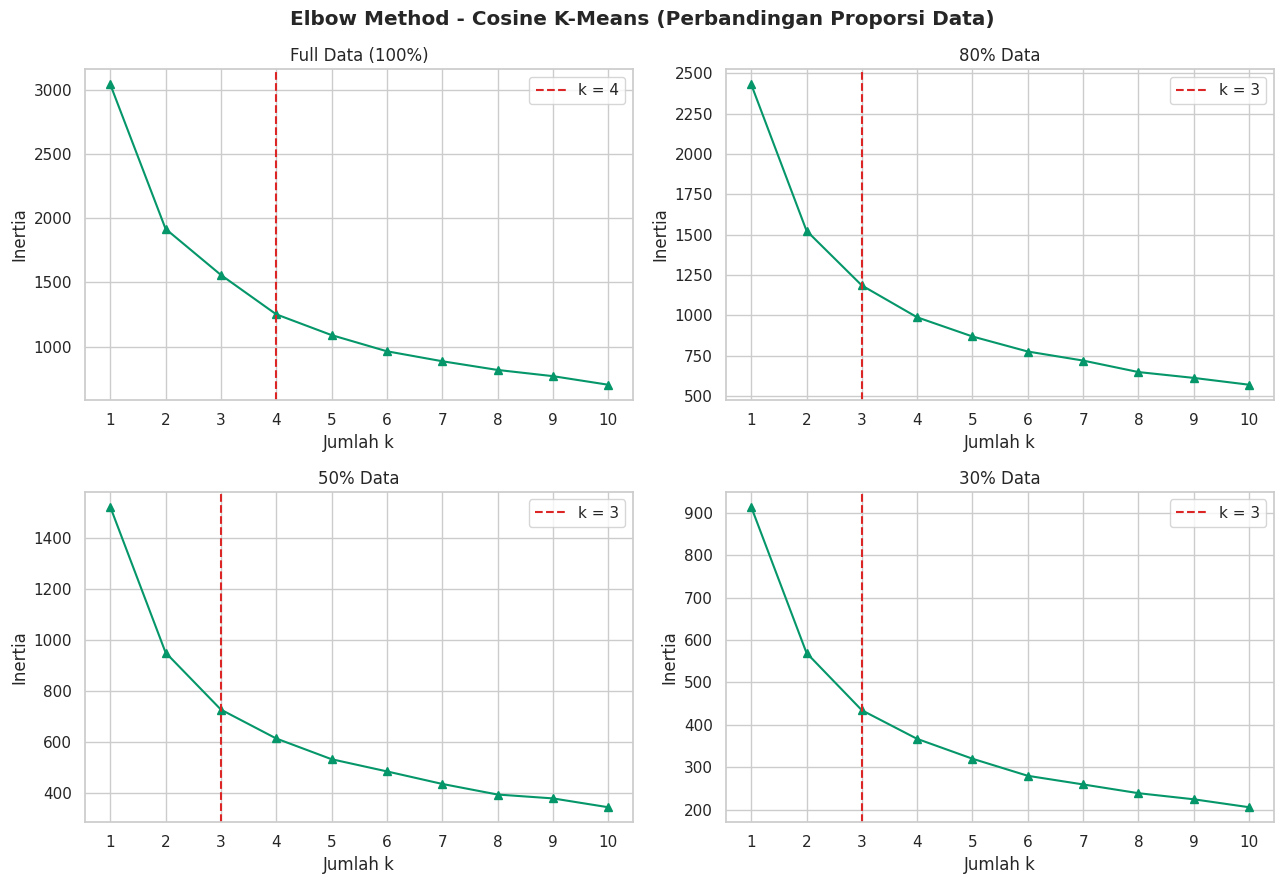

In [6]:
K_range = list(range(1, 11))
optimal_k = {}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (name, X) in zip(axes.ravel(), data_splits.items()):
    sse = [KMeansCosine(k, max_iter=200).fit(X).inertia_ for k in K_range]
    k_opt = optimal_k[name] = find_elbow_point(K_range, sse)
    print(f"{name:<18} -> k optimal = {k_opt} (inertia = {sse[k_opt - 1]:.2f})")

    ax.plot(K_range, sse, marker='^', color='#059669')
    ax.axvline(k_opt, color='#DC2626', linestyle='--', label=f'k = {k_opt}')
    ax.set(title=name, xlabel='Jumlah k', ylabel='Inertia', xticks=K_range)
    ax.legend()

plt.suptitle('Elbow Method - Cosine K-Means (Perbandingan Proporsi Data)', fontweight='bold')
plt.tight_layout()
plt.show()

# Langkah 6: Clustering Final + Metrik Evaluasi

In [7]:
models, rows = {}, []
for name, X in data_splits.items():
    k = max(optimal_k[name], 2)  # silhouette/DB/CH butuh minimal 2 klaster
    m = models[name] = KMeansCosine(k).fit(X)
    rows.append({
        'Skenario Data': name,
        'Jumlah Sampel': len(X),
        'Optimal k': k,
        'Silhouette Score (↑)': round(silhouette_score(X, m.labels_, metric='cosine'), 4),
        'Davies-Bouldin Index (↓)': round(davies_bouldin_score(X, m.labels_), 4),
        'Calinski-Harabasz Index (↑)': round(calinski_harabasz_score(X, m.labels_), 2),
        'Execution Time (s) (↓)': round(m.execution_time_, 5),
        'Iterations (↓)': m.n_iter_,
        'Objective Value (Inertia) (↓)': round(m.inertia_, 2),
    })

eval_df = pd.DataFrame(rows)
eval_df

,Skenario Data,Jumlah Sampel,Optimal k,Silhouette Score (↑),Davies-Bouldin Index (↓),Calinski-Harabasz Index (↑),Execution Time (s) (↓),Iterations (↓),Objective Value (Inertia) (↓)
0,Full Data (100%),3169,4,0.2926,1.6785,607.33,0.05685,24,1251.48
1,80% Data,2535,3,0.3093,1.9689,501.83,0.07826,47,1184.78
2,50% Data,1584,3,0.3153,1.8910,326.79,0.02305,11,727.19
3,30% Data,951,3,0.3195,1.8909,198.78,0.03472,16,434.39


# Langkah 7: Visualisasi PCA 2D Pemetaan Klaster

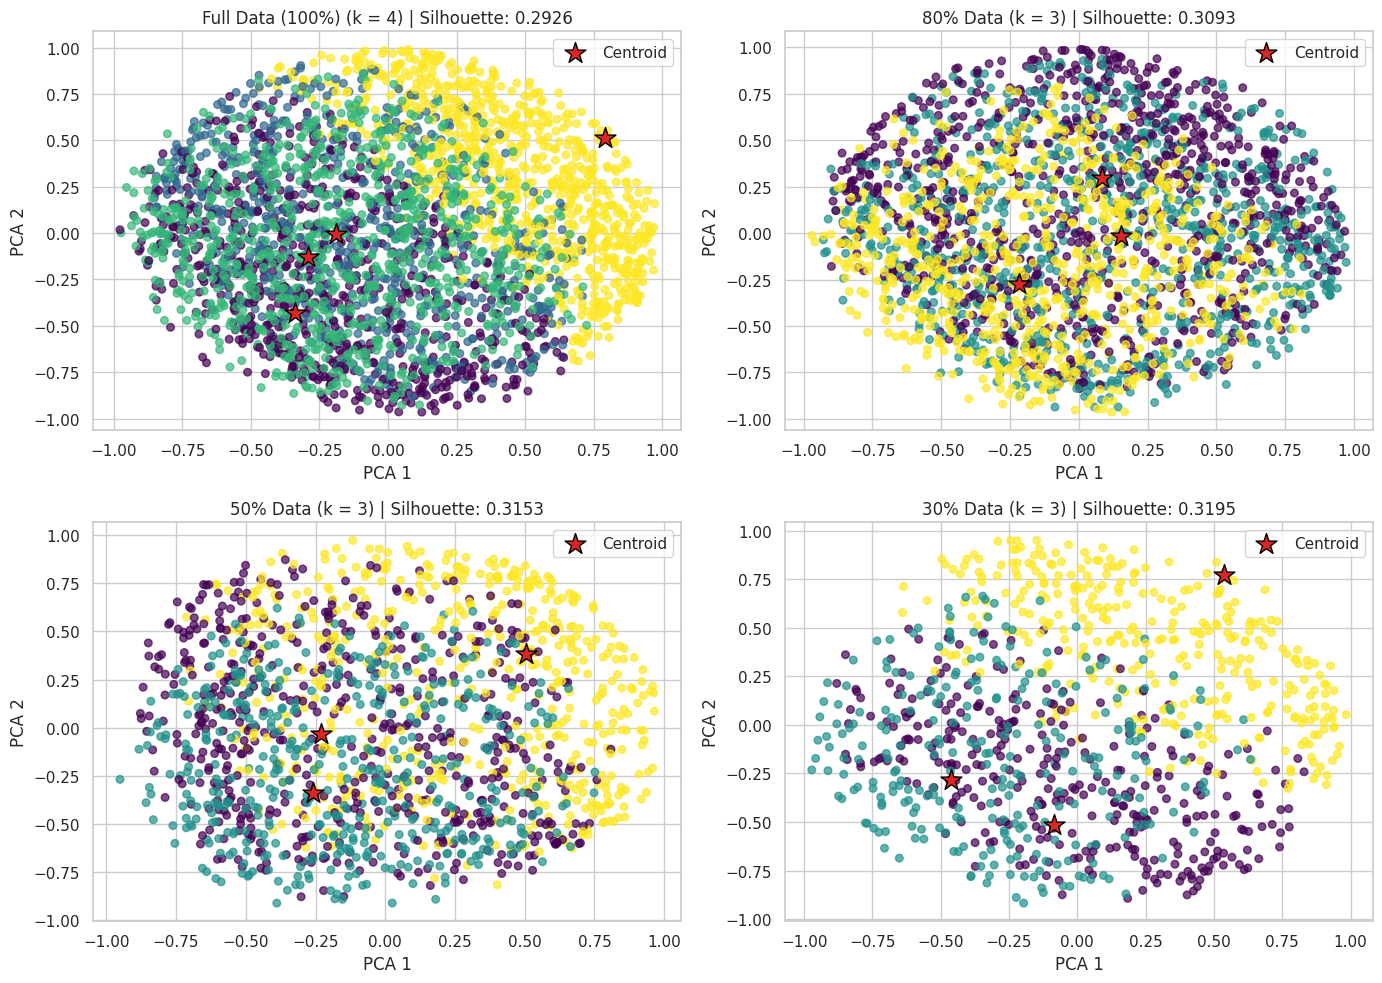

In [8]:
silhouette = eval_df.set_index('Skenario Data')['Silhouette Score (↑)']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (name, X) in zip(axes.ravel(), data_splits.items()):
    m = models[name]
    pca = PCA(n_components=2, random_state=RANDOM_STATE).fit(X)
    Z, C = pca.transform(X), pca.transform(m.centroids)

    ax.scatter(*Z.T, c=m.labels_, cmap='viridis', s=30, alpha=0.7)
    ax.scatter(*C.T, marker='*', s=250, c='#DC2626', edgecolor='black', label='Centroid')
    ax.set(title=f'{name} (k = {m.n_clusters}) | Silhouette: {silhouette[name]:.4f}', xlabel='PCA 1', ylabel='PCA 2')
    ax.legend()

plt.tight_layout()
plt.show()

# Langkah 8: Grafik Bar Perbandingan Metrik

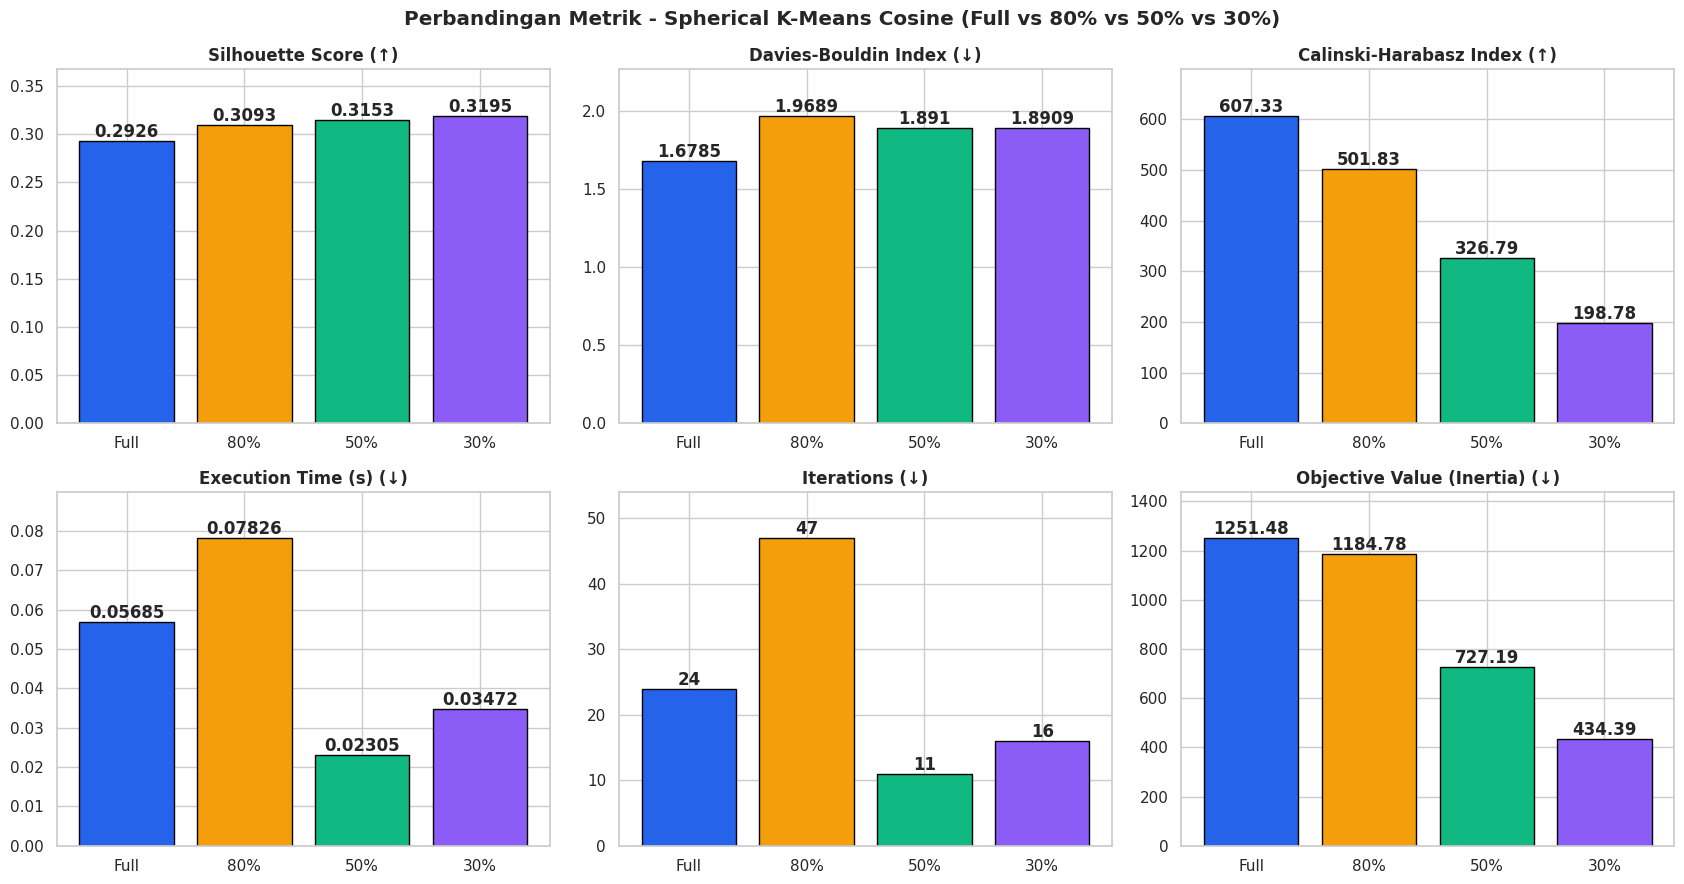

In [9]:
labels = [n.replace(' Data', '').replace(' (100%)', '') for n in eval_df['Skenario Data']]
colors = ['#2563EB', '#F59E0B', '#10B981', '#8B5CF6']

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, col in zip(axes.ravel(), eval_df.columns[3:]):
    bars = ax.bar(labels, eval_df[col], color=colors, edgecolor='black')
    ax.bar_label(bars, fmt='%g', fontweight='bold')
    ax.set_title(col, fontweight='bold')
    ax.margins(y=0.15)

plt.suptitle('Perbandingan Metrik - Spherical K-Means Cosine (Full vs 80% vs 50% vs 30%)', fontweight='bold')
plt.tight_layout()
plt.show()

K Optimal ditetapkan: 4 (Berdasarkan Full Data 100%)

-------------------------------------------------------
Full Data (100%)   -> k digunakan = 4 (inertia = 1251.48)
80% Data           -> k digunakan = 4 (inertia = 987.39)
50% Data           -> k digunakan = 4 (inertia = 614.25)
30% Data           -> k digunakan = 4 (inertia = 366.85)


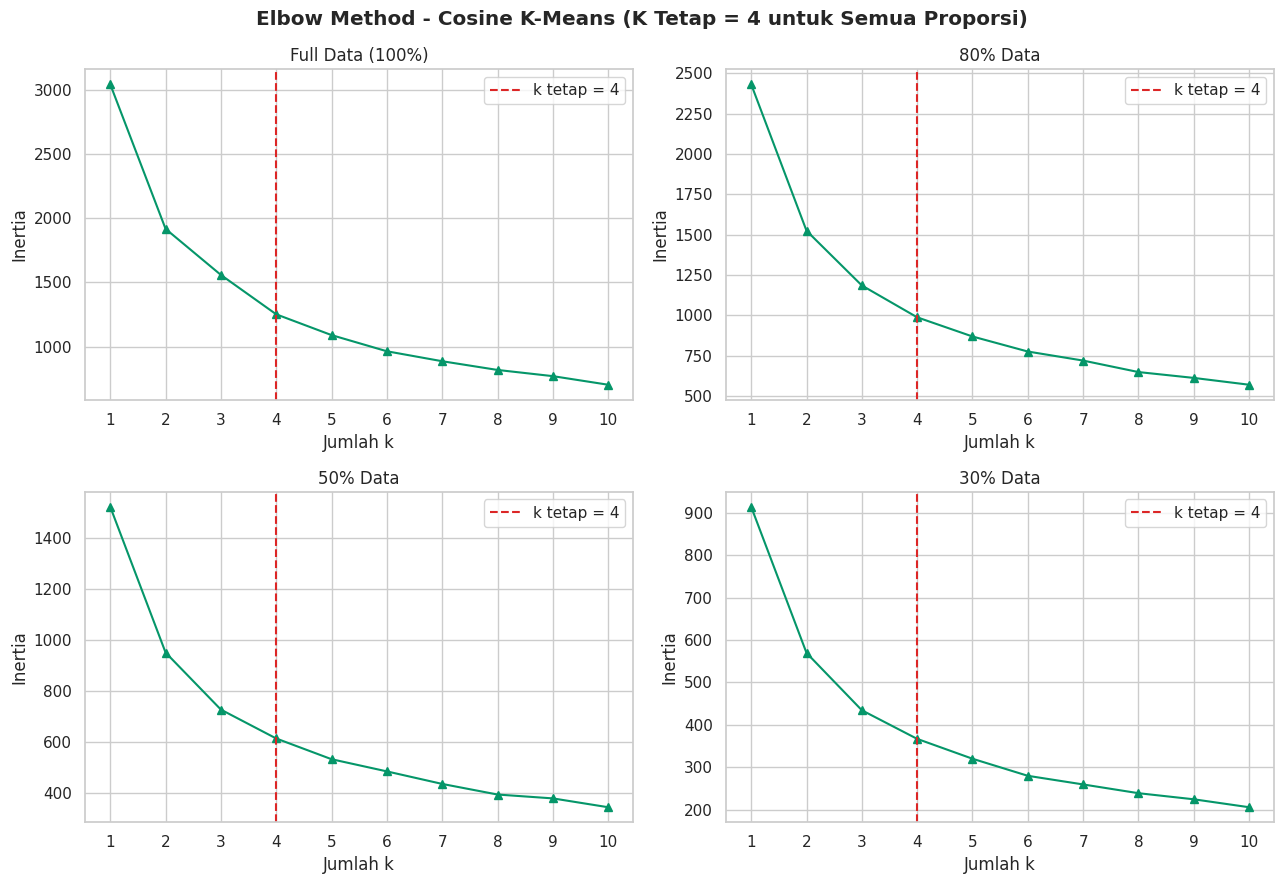

,Skenario Data,Jumlah Sampel,k Digunakan,Silhouette Score (↑),Davies-Bouldin Index (↓),Calinski-Harabasz Index (↑),Execution Time (s) (↓),Iterations (↓),Objective Value (Inertia) (↓)
0,Full Data (100%),3169,4,0.2926,1.6785,607.33,0.06368,24,1251.48
1,80% Data,2535,4,0.3006,1.6373,499.30,0.05332,25,987.39
2,50% Data,1584,4,0.3034,1.6304,314.71,0.29530,29,614.25
3,30% Data,951,4,0.3079,1.6201,190.64,0.08886,37,366.85


In [10]:
K_range = list(range(1, 11))
optimal_k = {}

# 1. Cari k optimal HANYA berdasarkan Full Data (100%)
X_full = data_splits["Full Data (100%)"]
sse_full = [KMeansCosine(k, max_iter=200).fit(X_full).inertia_ for k in K_range]
fixed_k = find_elbow_point(K_range, sse_full)

print(f"K Optimal ditetapkan: {fixed_k} (Berdasarkan Full Data 100%)\n")
print("-" * 55)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (name, X) in zip(axes.ravel(), data_splits.items()):
    # Tetap hitung SSE agar kurva masing-masing proporsi bisa diplot
    sse = [KMeansCosine(k, max_iter=200).fit(X).inertia_ for k in K_range]

    # 2. Paksa semua skenario menggunakan nilai k yang sama
    optimal_k[name] = fixed_k

    print(f"{name:<18} -> k digunakan = {fixed_k} (inertia = {sse[fixed_k - 1]:.2f})")

    ax.plot(K_range, sse, marker='^', color='#059669')
    # Tampilkan garis k_opt yang sudah dikunci
    ax.axvline(fixed_k, color='#DC2626', linestyle='--', label=f'k tetap = {fixed_k}')
    ax.set(title=name, xlabel='Jumlah k', ylabel='Inertia', xticks=K_range)
    ax.legend()

plt.suptitle(f'Elbow Method - Cosine K-Means (K Tetap = {fixed_k} untuk Semua Proporsi)', fontweight='bold')
plt.tight_layout()
plt.show()

models, rows = {}, []
for name, X in data_splits.items():
    k = max(optimal_k[name], 2)  # Mengambil nilai fixed_k (minimal 2 klaster untuk metrik)
    m = models[name] = KMeansCosine(k).fit(X)

    rows.append({
        'Skenario Data': name,
        'Jumlah Sampel': len(X),
        'k Digunakan': k,  # Ubah nama header untuk visualisasi tabel yang lebih jelas
        'Silhouette Score (↑)': round(silhouette_score(X, m.labels_, metric='cosine'), 4),
        'Davies-Bouldin Index (↓)': round(davies_bouldin_score(X, m.labels_), 4),
        'Calinski-Harabasz Index (↑)': round(calinski_harabasz_score(X, m.labels_), 2),
        'Execution Time (s) (↓)': round(m.execution_time_, 5),
        'Iterations (↓)': m.n_iter_,
        'Objective Value (Inertia) (↓)': round(m.inertia_, 2),
    })

eval_df = pd.DataFrame(rows)
eval_df

### Informasi & Eksplorasi Dataset Awal

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

In [11]:
import pandas as pd
print("Ukuran Dataset:", df.shape)
print("\nNama Kolom:", df.columns.tolist())
print("\nInformasi Dataset:")
df.info()
print("\nJumlah Missing Value:")
print(df.isnull().sum())

Ukuran Dataset: (3169, 9)

Nama Kolom: ['Plant_ID', 'Date', 'Temperature (°C)', 'Humidity (%)', 'TDS Value (ppm)', 'pH Level', 'Growth Days', 'Temperature (F)', 'Humidity']

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3169 entries, 0 to 3168
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Plant_ID          3169 non-null   int64  
 1   Date              3169 non-null   object 
 2   Temperature (°C)  3169 non-null   float64
 3   Humidity (%)      3169 non-null   int64  
 4   TDS Value (ppm)   3169 non-null   int64  
 5   pH Level          3169 non-null   float64
 6   Growth Days       3169 non-null   int64  
 7   Temperature (F)   3169 non-null   float64
 8   Humidity          3169 non-null   float64
dtypes: float64(4), int64(4), object(1)
memory usage: 222.9+ KB

Jumlah Missing Value:
Plant_ID            0
Date                0
Temperature (°C)    0
Humidity (%)        0
TDS Value

# Langkah 3: Preprocessing, seleksi fitur, standarisasi, dan Fungsi Pembagian Data

In [12]:
features = ['Temperature (°C)', 'Humidity (%)', 'TDS Value (ppm)', 'pH Level', 'Growth Days']
X_raw = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
df_scaled = pd.DataFrame(X_scaled, columns=features)

def get_data_splits(data):
    splits = {
        "Full Data (100%)": data.values,
        "80% Data": data.sample(frac=0.8, random_state=42).values,
        "50% Data": data.sample(frac=0.5, random_state=42).values,
        "30% Data": data.sample(frac=0.3, random_state=42).values
    }
    return splits

data_splits = get_data_splits(df_scaled)

for name, data in data_splits.items():
    print(f"{name}: {len(data)} baris")

Full Data (100%): 3169 baris
80% Data: 2535 baris
50% Data: 1584 baris
30% Data: 951 baris


In [13]:
class CustomKMeans:
    def __init__(self, n_clusters=3, max_iters=100, metric='euclidean'):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.metric = metric
        self.centroids = None
        self.labels = None
        self.inertia_ = 0

    def fit(self, X):
        np.random.seed(42)
        random_idx = np.random.choice(len(X), self.n_clusters, replace=False)
        self.centroids = X[random_idx]

        for _ in range(self.max_iters):
            distances = cdist(X, self.centroids, metric=self.metric)
            self.labels = np.argmin(distances, axis=1)

            new_centroids = np.zeros((self.n_clusters, X.shape[1]))
            for i in range(self.n_clusters):
                cluster_data = X[self.labels == i]
                if len(cluster_data) > 0:
                    new_centroids[i] = np.mean(cluster_data, axis=0)
                else:
                    new_centroids[i] = self.centroids[i]

            if np.allclose(self.centroids, new_centroids):
                break
            self.centroids = new_centroids

        final_dist = cdist(X, self.centroids, metric=self.metric)
        min_dist = np.min(final_dist, axis=1)
        self.inertia_ = np.sum(min_dist**2)

        return self

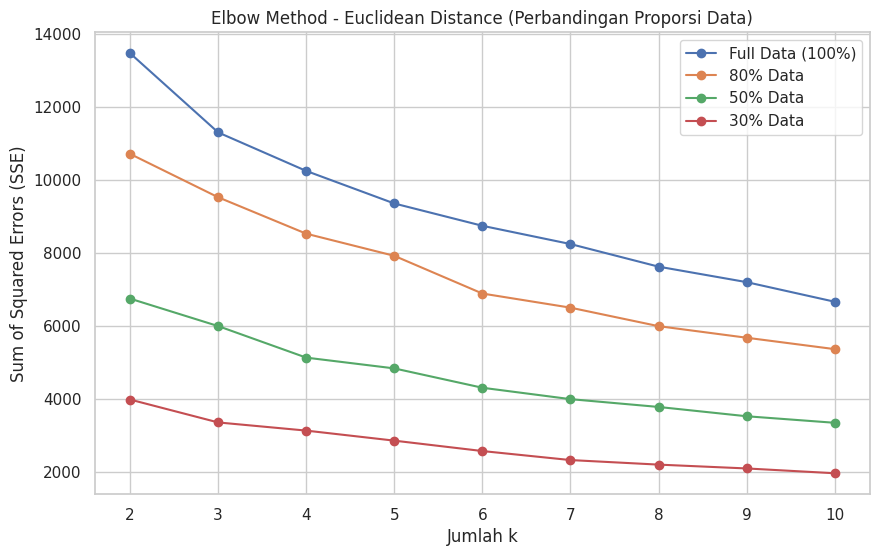

In [18]:
plt.figure(figsize=(10, 6))
K_range = range(2, 11)

for name, X_data in data_splits.items():
    sse = []
    for k in K_range:
        model = CustomKMeans(n_clusters=k, metric='euclidean')
        model.fit(X_data)
        sse.append(model.inertia_)
    plt.plot(K_range, sse, marker='o', label=name)

plt.xlabel('Jumlah k')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.title('Elbow Method - Euclidean Distance (Perbandingan Proporsi Data)')
plt.legend()
plt.xticks(K_range)
plt.show()

# Hasil

Jumlah k yang saya gunakan berdasarkan elbow method dan Silhouette score adalah 4. Dikarenakan mempunyai nilai silhouette score yang paling stabil terhadap perubahan data.

In [19]:
k_optimal = 4
euclidean_results = {}

print(f"Hasil Evaluasi Euclidean Distance (k= {k_optimal})")
for name, X_data in data_splits.items():
    model = CustomKMeans(n_clusters=k_optimal, metric='euclidean')
    model.fit(X_data)
    score = silhouette_score(X_data, model.labels, metric='euclidean')
    euclidean_results[name] = score

    print(f"{name:<20} | Silhouette Score: {score:.4f} | Inertia: {model.inertia_:.2f}")

Hasil Evaluasi Euclidean Distance (k= 4)
Full Data (100%)     | Silhouette Score: 0.1547 | Inertia: 10258.11
80% Data             | Silhouette Score: 0.1527 | Inertia: 8538.81
50% Data             | Silhouette Score: 0.1576 | Inertia: 5143.96
30% Data             | Silhouette Score: 0.1775 | Inertia: 3144.81


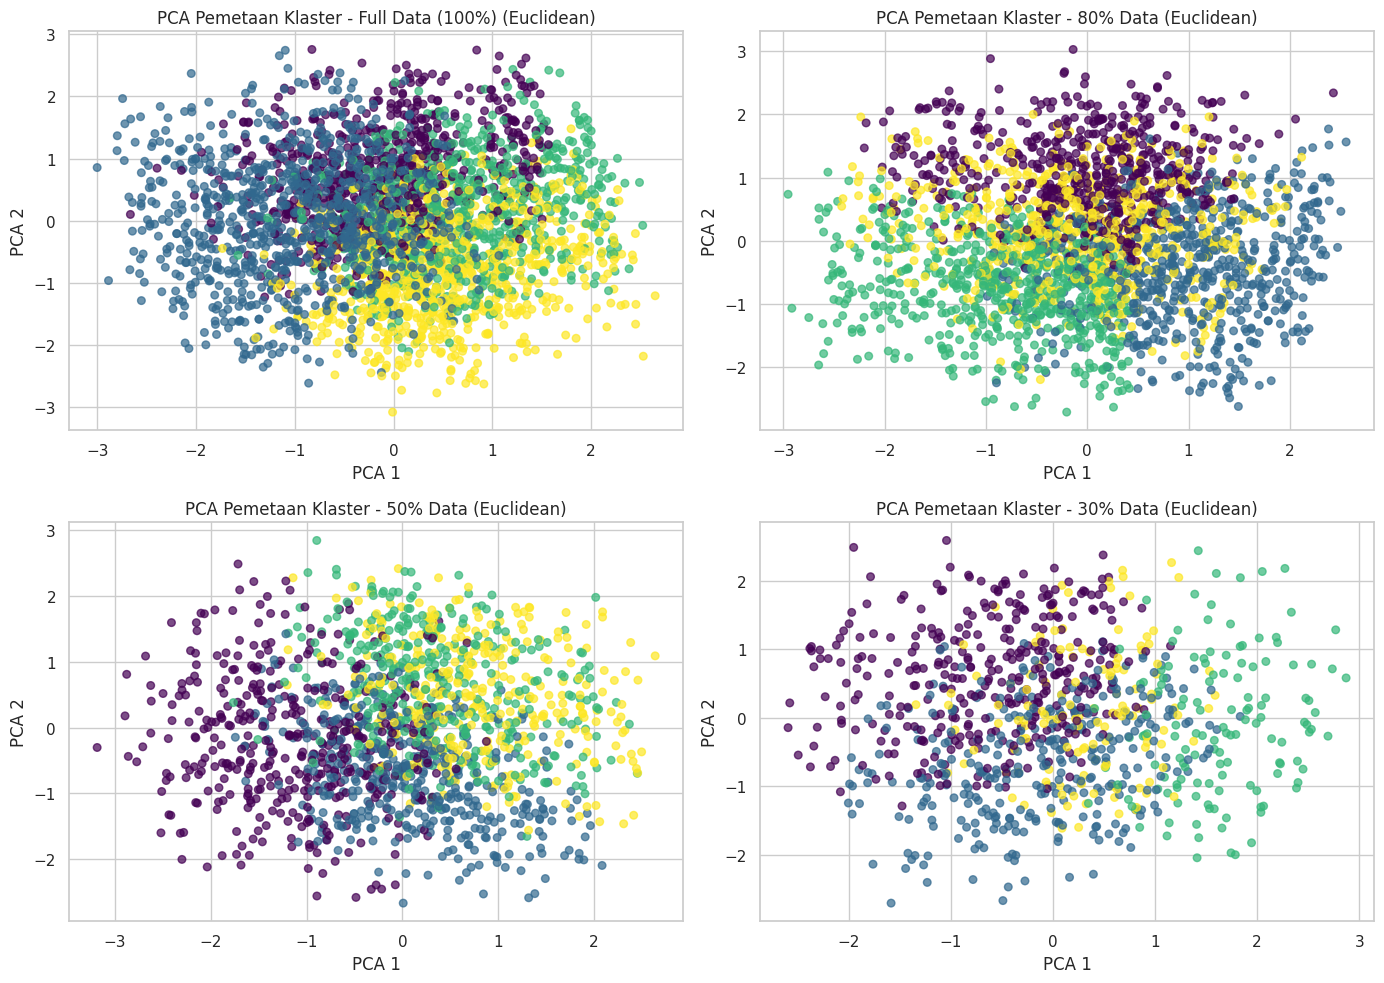

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, (name, X_data) in enumerate(data_splits.items()):
    model = CustomKMeans(n_clusters=k_optimal, metric='euclidean')
    model.fit(X_data)

    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_data)

    scatter = axes[idx].scatter(X_pca[:, 0], X_pca[:, 1], c=model.labels, cmap='viridis', s=30, alpha=0.7)
    axes[idx].set_title(f'PCA Pemetaan Klaster - {name} (Euclidean)')
    axes[idx].set_xlabel('PCA 1')
    axes[idx].set_ylabel('PCA 2')

plt.tight_layout()
plt.show()

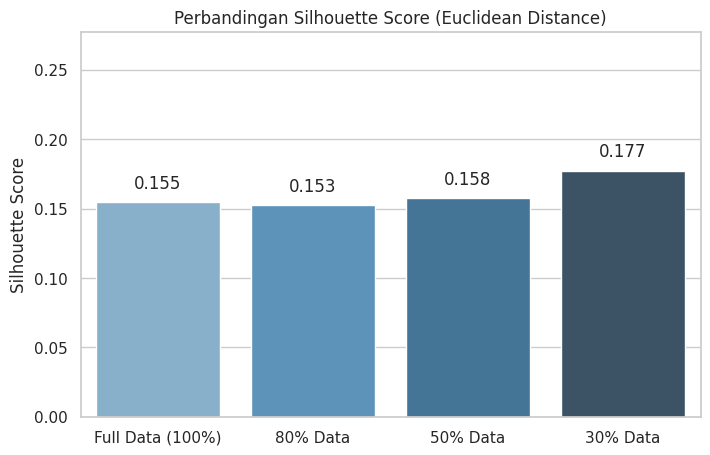

In [21]:
names = list(euclidean_results.keys())
scores = list(euclidean_results.values())

plt.figure(figsize=(8, 5))
sns.barplot(x=names, y=scores, palette='Blues_d')
plt.title('Perbandingan Silhouette Score (Euclidean Distance)')
plt.ylabel('Silhouette Score')
plt.ylim(0, max(scores) + 0.1)

for i, score in enumerate(scores):
    plt.text(i, score + 0.01, f'{score:.3f}', ha='center')

plt.show()

Metode Manhattan Distance

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

In [23]:
df = pd.read_csv('lettuce_dataset_updated.csv', encoding='latin1')
print(f"Total data awal: {df.shape[0]} baris, {df.shape[1]} kolom")

Total data awal: 3169 baris, 9 kolom


In [24]:
features = ['Temperature (°C)', 'Humidity (%)', 'TDS Value (ppm)', 'pH Level', 'Growth Days']
X_raw = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
df_scaled = pd.DataFrame(X_scaled, columns=features)

def get_data_splits(data):
    splits = {
        "Full Data (100%)": data.values,
        "80% Data": data.sample(frac=0.8, random_state=42).values,
        "50% Data": data.sample(frac=0.5, random_state=42).values,
        "30% Data": data.sample(frac=0.3, random_state=42).values
    }
    return splits

data_splits = get_data_splits(df_scaled)

In [25]:
class CustomKMedians:
    def __init__(self, n_clusters=3, max_iters=100, metric='cityblock'):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.metric = metric
        self.centroids = None
        self.labels = None
        self.inertia_ = 0

    def fit(self, X):
        np.random.seed(42)
        random_idx = np.random.choice(len(X), self.n_clusters, replace=False)
        self.centroids = X[random_idx]

        for _ in range(self.max_iters):
            distances = cdist(X, self.centroids, metric=self.metric)
            self.labels = np.argmin(distances, axis=1)

            new_centroids = np.zeros((self.n_clusters, X.shape[1]))
            for i in range(self.n_clusters):
                cluster_data = X[self.labels == i]
                if len(cluster_data) > 0:
                    new_centroids[i] = np.median(cluster_data, axis=0)
                else:
                    new_centroids[i] = self.centroids[i]

            if np.allclose(self.centroids, new_centroids):
                break
            self.centroids = new_centroids

        # Hitung Error absolut
        final_dist = cdist(X, self.centroids, metric=self.metric)
        self.inertia_ = np.sum(np.min(final_dist, axis=1))

        return self

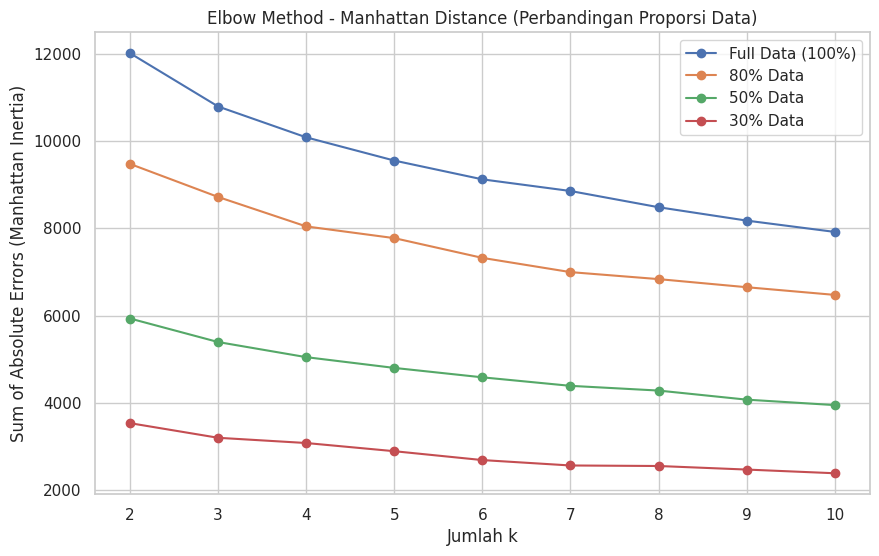

In [26]:
plt.figure(figsize=(10, 6))
K_range = range(2, 11)

for name, X_data in data_splits.items():
    sse = []
    for k in K_range:
        model = CustomKMedians(n_clusters=k, metric='cityblock')
        model.fit(X_data)
        sse.append(model.inertia_)
    plt.plot(K_range, sse, marker='o', label=name)

plt.xlabel('Jumlah k')
plt.ylabel('Sum of Absolute Errors (Manhattan Inertia)')
plt.title('Elbow Method - Manhattan Distance (Perbandingan Proporsi Data)')
plt.legend()
plt.xticks(K_range)
plt.show()

In [27]:
k_optimal = 6
manhattan_results = {}

print(f"Hasil Evaluasi Manhattan Distance (k= {k_optimal})")
for name, X_data in data_splits.items():
    model = CustomKMedians(n_clusters=k_optimal, metric='cityblock')
    model.fit(X_data)
    score = silhouette_score(X_data, model.labels, metric='cityblock')
    manhattan_results[name] = score

    print(f"{name:<20} | Silhouette Score: {score:.4f} | Absolute Error: {model.inertia_:.2f}")

Hasil Evaluasi Manhattan Distance (k= 6)
Full Data (100%)     | Silhouette Score: 0.1518 | Absolute Error: 9123.38
80% Data             | Silhouette Score: 0.1621 | Absolute Error: 7324.62
50% Data             | Silhouette Score: 0.1630 | Absolute Error: 4588.92
30% Data             | Silhouette Score: 0.1672 | Absolute Error: 2693.73


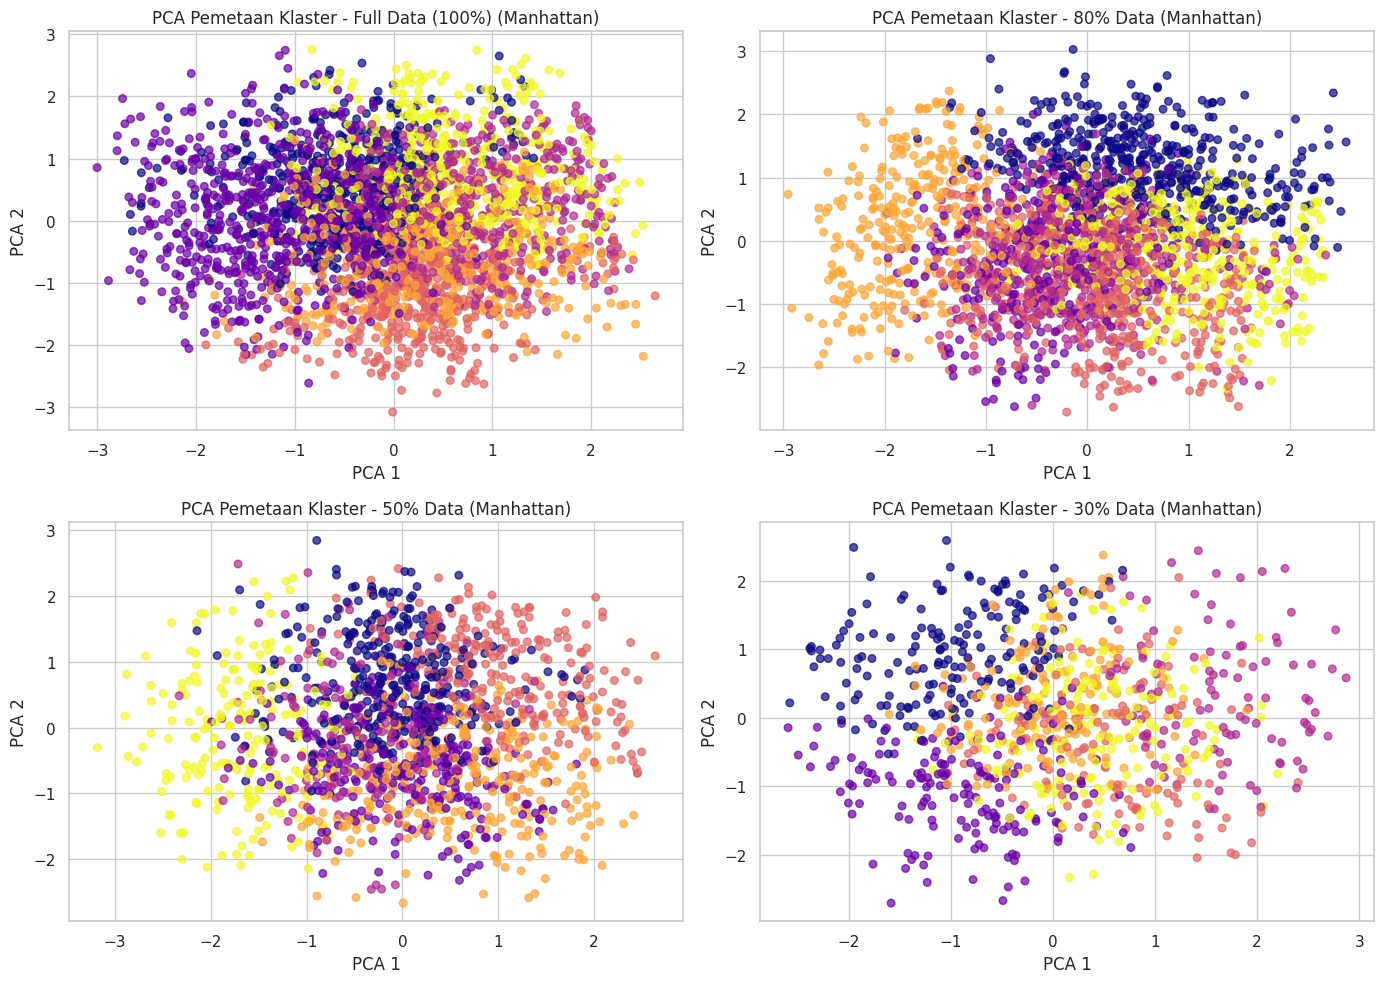

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, (name, X_data) in enumerate(data_splits.items()):
    model = CustomKMedians(n_clusters=k_optimal, metric='cityblock')
    model.fit(X_data)

    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_data)

    scatter = axes[idx].scatter(X_pca[:, 0], X_pca[:, 1], c=model.labels, cmap='plasma', s=30, alpha=0.7)
    axes[idx].set_title(f'PCA Pemetaan Klaster - {name} (Manhattan)')
    axes[idx].set_xlabel('PCA 1')
    axes[idx].set_ylabel('PCA 2')

plt.tight_layout()
plt.show()

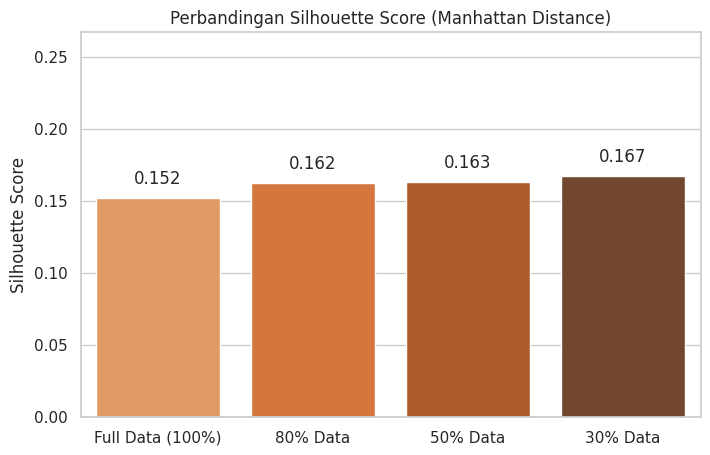

In [29]:
names = list(manhattan_results.keys())
scores = list(manhattan_results.values())

plt.figure(figsize=(8, 5))
sns.barplot(x=names, y=scores, palette='Oranges_d')
plt.title('Perbandingan Silhouette Score (Manhattan Distance)')
plt.ylabel('Silhouette Score')
plt.ylim(0, max(scores) + 0.1)

for i, score in enumerate(scores):
    plt.text(i, score + 0.01, f'{score:.3f}', ha='center')

plt.show()

DBSCAN CORE SAMPLE/INSTANCE

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
RANDOM_STATE = 42

In [32]:
df = pd.read_csv('lettuce_dataset_updated.csv', encoding = "latin-1")

df.head()

,Plant_ID,Date,Temperature (°C),Humidity (%),TDS Value (ppm),pH Level,Growth Days,Temperature (F),Humidity
0,1,8/3/2023,33.4,53,582,6.4,1,92.12,0.53
1,1,8/4/2023,33.5,53,451,6.1,2,92.30,0.53
2,1,8/5/2023,33.4,59,678,6.4,3,92.12,0.59
3,1,8/6/2023,33.4,68,420,6.4,4,92.12,0.68
4,1,8/7/2023,33.4,74,637,6.5,5,92.12,0.74


Jumlah baris: 3169 | Jumlah kolom: 9

Nama kolom: ['Plant_ID', 'Date', 'Temperature (°C)', 'Humidity (%)', 'TDS Value (ppm)', 'pH Level', 'Growth Days', 'Temperature (F)', 'Humidity']

Tipe data:
 Plant_ID              int64
Date                 object
Temperature (°C)    float64
Humidity (%)          int64
TDS Value (ppm)       int64
pH Level            float64
Growth Days           int64
Temperature (F)     float64
Humidity            float64
dtype: object

10 data pertama:


,Plant_ID,Date,Temperature (°C),Humidity (%),TDS Value (ppm),pH Level,Growth Days,Temperature (F),Humidity
0,1,8/3/2023,33.4,53,582,6.4,1,92.12,0.53
1,1,8/4/2023,33.5,53,451,6.1,2,92.30,0.53
2,1,8/5/2023,33.4,59,678,6.4,3,92.12,0.59
3,1,8/6/2023,33.4,68,420,6.4,4,92.12,0.68
4,1,8/7/2023,33.4,74,637,6.5,5,92.12,0.74
5,1,8/8/2023,32.3,77,478,6.8,6,90.14,0.77
6,1,8/9/2023,32.3,75,682,6.0,7,90.14,0.75
7,1,8/10/2023,22.7,63,576,6.3,8,72.86,0.63
8,1,8/11/2023,31.9,69,662,6.1,9,89.42,0.69
9,1,8/12/2023,30.2,59,607,6.2,10,86.36,0.59



10 data terakhir:


,Plant_ID,Date,Temperature (°C),Humidity (%),TDS Value (ppm),pH Level,Growth Days,Temperature (F),Humidity
3159,70,9/8/2023,23.6,54,649,6.1,37,74.48,0.54
3160,70,9/9/2023,21.6,80,506,6.7,38,70.88,0.80
3161,70,9/10/2023,24.6,67,407,6.1,39,76.28,0.67
3162,70,9/11/2023,21.2,66,500,6.8,40,70.16,0.66
3163,70,9/12/2023,22.6,58,799,6.3,41,72.68,0.58
3164,70,9/13/2023,19.4,72,475,6.1,42,66.92,0.72
3165,70,9/14/2023,22.5,80,668,6.7,43,72.50,0.80
3166,70,9/15/2023,22.5,62,476,6.6,44,72.50,0.62
3167,70,9/16/2023,24.6,79,621,6.0,45,76.28,0.79
3168,70,9/17/2023,22.6,69,521,6.5,46,72.68,0.69



info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3169 entries, 0 to 3168
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Plant_ID          3169 non-null   int64  
 1   Date              3169 non-null   object 
 2   Temperature (°C)  3169 non-null   float64
 3   Humidity (%)      3169 non-null   int64  
 4   TDS Value (ppm)   3169 non-null   int64  
 5   pH Level          3169 non-null   float64
 6   Growth Days       3169 non-null   int64  
 7   Temperature (F)   3169 non-null   float64
 8   Humidity          3169 non-null   float64
dtypes: float64(4), int64(4), object(1)
memory usage: 222.9+ KB

describe():
                   count        mean         std    min     25%     50%     75%    max
Plant_ID          3169.0   35.441780   20.243433    1.0   18.00   35.00   53.00   70.0
Temperature (°C)  3169.0   28.142222    4.670521   18.0   23.60   30.20   31.50   33.5
Humidity (%)      3169.0   64.

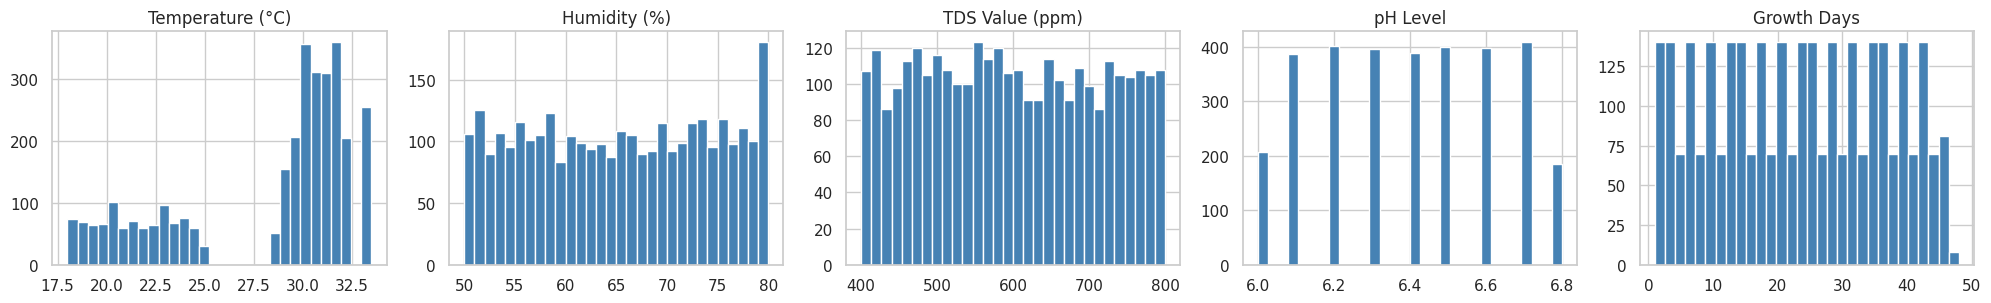


Korelasi antar fitur numerik:
                  Temperature (°C)  Humidity (%)  TDS Value (ppm)  pH Level  Growth Days
Temperature (°C)              1.00          0.03            -0.01      0.01        -0.07
Humidity (%)                  0.03          1.00            -0.01      0.02        -0.01
TDS Value (ppm)              -0.01         -0.01             1.00     -0.01        -0.02
pH Level                      0.01          0.02            -0.01      1.00         0.00
Growth Days                  -0.07         -0.01            -0.02      0.00         1.00


In [33]:
# CELL 3 — Eksplorasi Dataset
print("Jumlah baris:", df.shape[0], "| Jumlah kolom:", df.shape[1])
print("\nNama kolom:", list(df.columns))
print("\nTipe data:\n", df.dtypes)
print("\n10 data pertama:"); display(df.head(10))
print("\n10 data terakhir:"); display(df.tail(10))
print("\ninfo():"); df.info()
print("\ndescribe():"); print(df.describe().T)
print("\nMissing value per kolom:\n", df.isna().sum())
print("\nJumlah duplicated row:", df.duplicated().sum())
print("\nJumlah unique value per kolom:\n", df.nunique())
print("\nJumlah baris per Plant_ID:", df["Plant_ID"].value_counts().describe()[["min", "max"]].to_dict())

print("\nTemperature (F) == C*9/5+32 ? ->",
      np.allclose(df["Temperature (°C)"] * 9/5 + 32, df["Temperature (F)"]))
print("Humidity == Humidity(%)/100 ? ->",
      np.allclose(df["Humidity (%)"] / 100, df["Humidity"]))

num_cols = ["Temperature (°C)", "Humidity (%)", "TDS Value (ppm)", "pH Level", "Growth Days"]
fig, axes = plt.subplots(1, 5, figsize=(20, 3.2))
for ax, c in zip(axes, num_cols):
    ax.hist(df[c], bins=30, color="steelblue", edgecolor="white"); ax.set_title(c)
plt.tight_layout(); plt.show()
print("\nKorelasi antar fitur numerik:"); print(df[num_cols].corr().round(2))

In [34]:
# CELL 4 — Data Cleaning
n_awal = len(df)
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y")
print("Missing value total :", int(df.isna().sum().sum()))
print("Duplikat (semua kolom):", df.duplicated().sum())

# Hapus KOLOM redundan (bukan baris)
df_clean = df.drop(columns=["Temperature (F)", "Humidity"])

# Outlier (IQR) hanya dicek, tidak dihapus
sensor_cols = ["Temperature (°C)", "Humidity (%)", "TDS Value (ppm)", "pH Level", "Growth Days"]
for c in sensor_cols:
    q1, q3 = df_clean[c].quantile([0.25, 0.75]); iqr = q3 - q1
    n_out = ((df_clean[c] < q1 - 1.5*iqr) | (df_clean[c] > q3 + 1.5*iqr)).sum()
    print(f"Outlier IQR {c:18s}: {n_out}")
print(f"Baris sebelum: {n_awal} | sesudah: {len(df_clean)} (tidak ada baris dihapus)")

Missing value total : 0
Duplikat (semua kolom): 0
Outlier IQR Temperature (°C)  : 0
Outlier IQR Humidity (%)      : 0
Outlier IQR TDS Value (ppm)   : 0
Outlier IQR pH Level          : 0
Outlier IQR Growth Days       : 0
Baris sebelum: 3169 | sesudah: 3169 (tidak ada baris dihapus)


In [35]:
# CELL 5 — Menentukan Fitur
features = ["Temperature (°C)", "Humidity (%)", "TDS Value (ppm)", "pH Level", "Growth Days"]
X = df_clean[features].copy()
print("Fitur clustering:", features)
print("Seluruhnya numerik:", all(pd.api.types.is_numeric_dtype(X[c]) for c in features))
print("Duplikat pada kombinasi 5 fitur:", X.duplicated().sum(), "(dipertahankan: pengukuran berbeda)")

Fitur clustering: ['Temperature (°C)', 'Humidity (%)', 'TDS Value (ppm)', 'pH Level', 'Growth Days']
Seluruhnya numerik: True
Duplikat pada kombinasi 5 fitur: 1 (dipertahankan: pengukuran berbeda)


In [36]:
# CELL 6 — Membagi Dataset
df_full = X.copy()
df_80   = X.sample(frac=0.8, random_state=RANDOM_STATE)
df_50   = X.sample(frac=0.5, random_state=RANDOM_STATE)
df_30   = X.sample(frac=0.3, random_state=RANDOM_STATE)

subsets = {"100%": df_full, "80%": df_80, "50%": df_50, "30%": df_30}
print(f"Full Data : {len(df_full)} rows")
print(f"80% Data  : {len(df_80)} rows")
print(f"50% Data  : {len(df_50)} rows")
print(f"30% Data  : {len(df_30)} rows")

Full Data : 3169 rows
80% Data  : 2535 rows
50% Data  : 1584 rows
30% Data  : 951 rows


In [37]:
# CELL 7 — Scaling
scaler = StandardScaler().fit(df_full)
scaled = {name: pd.DataFrame(scaler.transform(d), index=d.index, columns=features)
          for name, d in subsets.items()}
print("Mean (full):", scaled["100%"].mean().round(3).to_dict())
print("Std  (full):", scaled["100%"].std(ddof=0).round(3).to_dict())

Mean (full): {'Temperature (°C)': -0.0, 'Humidity (%)': -0.0, 'TDS Value (ppm)': -0.0, 'pH Level': 0.0, 'Growth Days': 0.0}
Std  (full): {'Temperature (°C)': 1.0, 'Humidity (%)': 1.0, 'TDS Value (ppm)': 1.0, 'pH Level': 1.0, 'Growth Days': 1.0}


min_samples = 10
eps (knee k-distance, full data) = 0.96


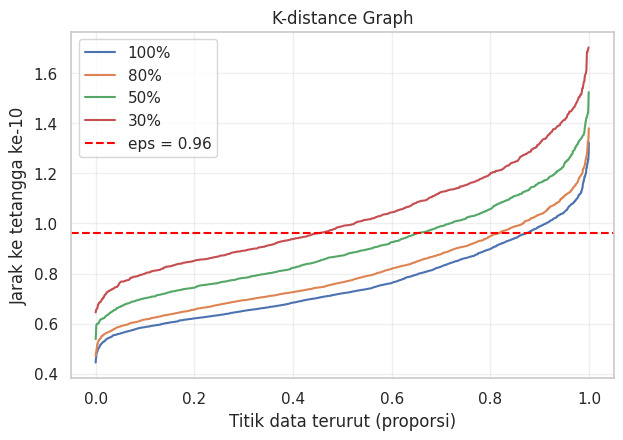

In [38]:
# CELL 8 — Parameter DBSCAN
def k_distances(Xs, k):
    nn = NearestNeighbors(n_neighbors=k).fit(Xs)
    d, _ = nn.kneighbors(Xs)
    return np.sort(d[:, -1])

def find_knee(kd):
    x = np.arange(len(kd)); y = kd
    p1, p2 = np.array([x[0], y[0]]), np.array([x[-1], y[-1]])
    v = (p2 - p1) / np.linalg.norm(p2 - p1)
    pts = np.c_[x, y] - p1
    dist = np.abs(pts[:, 0]*v[1] - pts[:, 1]*v[0])
    return int(np.argmax(dist))

MIN_SAMPLES = 2 * len(features)
kd_all = {name: k_distances(Xs.values, MIN_SAMPLES) for name, Xs in scaled.items()}
knee_idx = find_knee(kd_all["100%"])
EPS = round(float(kd_all["100%"][knee_idx]), 2)
print(f"min_samples = {MIN_SAMPLES}")
print(f"eps (knee k-distance, full data) = {EPS}")

plt.figure(figsize=(7, 4.5))
for name, kd in kd_all.items():
    plt.plot(np.arange(len(kd)) / len(kd), kd, label=name)
plt.axhline(EPS, color="red", ls="--", label=f"eps = {EPS}")
plt.xlabel("Titik data terurut (proporsi)"); plt.ylabel(f"Jarak ke tetangga ke-{MIN_SAMPLES}")
plt.title("K-distance Graph"); plt.legend(); plt.grid(alpha=.3); plt.show()

In [39]:
# CELL 9–12 — DBSCAN pada 100%, 80%, 50%, 30%
def run_dbscan(Xs, eps, min_samples):
    return DBSCAN(eps=eps, min_samples=min_samples).fit_predict(Xs)

def cluster_summary(labels):
    unique, counts = np.unique(labels, return_counts=True)
    sizes = {int(u): int(c) for u, c in zip(unique, counts) if u != -1}
    n_noise = int((labels == -1).sum())
    return len(sizes), n_noise, 100 * n_noise / len(labels), sizes

results, labels_dict = [], {}
for name in ["100%", "80%", "50%", "30%"]:
    labels = run_dbscan(scaled[name].values, EPS, MIN_SAMPLES)
    labels_dict[name] = pd.Series(labels, index=scaled[name].index)
    n_cl, n_noise, pct_noise, sizes = cluster_summary(labels)
    print(f"\n=== DBSCAN {name} (n={len(labels)}) ===")
    print(f"Jumlah cluster : {n_cl}")
    print(f"Jumlah noise   : {n_noise} ({pct_noise:.2f}%)")
    print(f"Anggota cluster: {sizes}")


=== DBSCAN 100% (n=3169) ===
Jumlah cluster : 2
Jumlah noise   : 27 (0.85%)
Anggota cluster: {0: 2214, 1: 928}

=== DBSCAN 80% (n=2535) ===
Jumlah cluster : 3
Jumlah noise   : 80 (3.16%)
Anggota cluster: {0: 1774, 1: 672, 2: 9}

=== DBSCAN 50% (n=1584) ===
Jumlah cluster : 8
Jumlah noise   : 222 (14.02%)
Anggota cluster: {0: 1103, 1: 23, 2: 145, 3: 9, 4: 13, 5: 39, 6: 8, 7: 22}

=== DBSCAN 30% (n=951) ===
Jumlah cluster : 3
Jumlah noise   : 282 (29.65%)
Anggota cluster: {0: 628, 1: 31, 2: 10}


In [40]:
# CELL 13 — Evaluasi
def evaluate_clustering(Xs, labels):
    mask = labels != -1
    n_cl = len(set(labels[mask]))
    out = {"Jumlah Cluster": n_cl, "Jumlah Noise": int((~mask).sum()),
           "Persentase Noise (%)": round(100 * (~mask).sum() / len(labels), 2),
           "Silhouette Score": np.nan, "Davies-Bouldin": np.nan}
    if n_cl >= 2 and mask.sum() > n_cl:      # syarat minimal 2 cluster
        out["Silhouette Score"] = round(silhouette_score(Xs[mask], labels[mask]), 4)
        out["Davies-Bouldin"]   = round(davies_bouldin_score(Xs[mask], labels[mask]), 4)
    return out

rows = []
for name in ["100%", "80%", "50%", "30%"]:
    ev = evaluate_clustering(scaled[name].values, labels_dict[name].values)
    idx = labels_dict[name].index
    ari = adjusted_rand_score(labels_dict["100%"].loc[idx], labels_dict[name])
    rows.append({"Dataset": name, "Jumlah Data": len(idx), **ev, "ARI vs Full": round(ari, 4)})

Explained variance ratio: [0.217 0.206] | total: 0.423


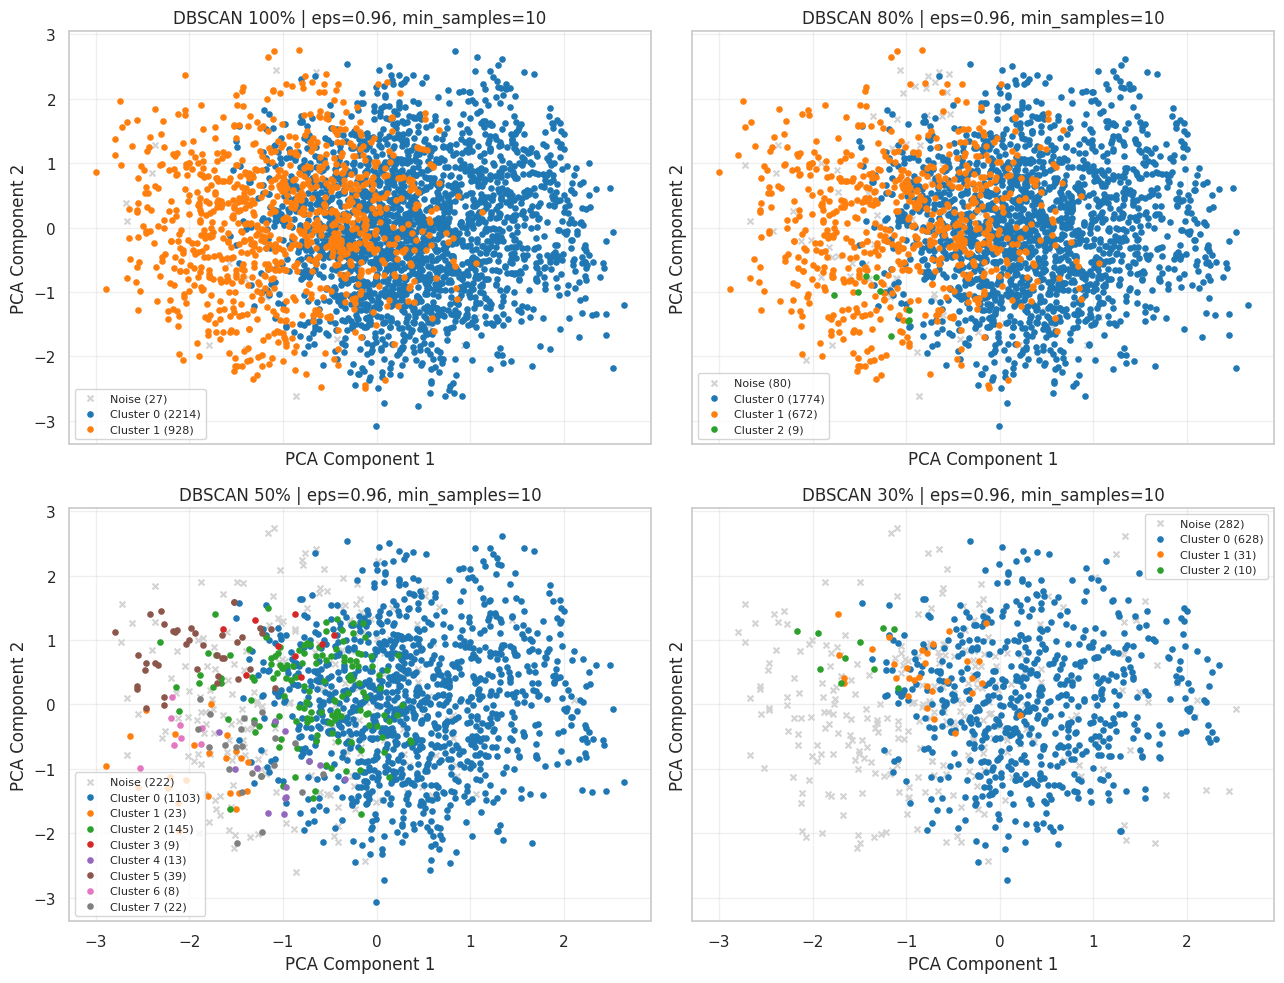

In [41]:
# CELL 14 — Visualisasi PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE).fit(scaled["100%"])
print("Explained variance ratio:", pca.explained_variance_ratio_.round(3),
      "| total:", pca.explained_variance_ratio_.sum().round(3))

fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharex=True, sharey=True)
palette = plt.cm.tab10.colors
for ax, name in zip(axes.ravel(), ["100%", "80%", "50%", "30%"]):
    P = pca.transform(scaled[name]); lab = labels_dict[name].values
    noise = lab == -1
    ax.scatter(P[noise, 0], P[noise, 1], c="lightgray", marker="x", s=18, label=f"Noise ({noise.sum()})")
    for c in sorted(set(lab) - {-1}):
        m = lab == c
        ax.scatter(P[m, 0], P[m, 1], s=14, color=palette[c % 10], label=f"Cluster {c} ({m.sum()})")
    ax.set_title(f"DBSCAN {name} | eps={EPS}, min_samples={MIN_SAMPLES}")
    ax.set_xlabel("PCA Component 1"); ax.set_ylabel("PCA Component 2")
    ax.legend(fontsize=8, loc="best"); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

In [42]:
# CELL 15 — Tabel Perbandingan
comparison = pd.DataFrame(rows).set_index("Dataset")
display(comparison)

# Sensitivitas 1: min_samples diskalakan sebanding ukuran data
rows2 = []
for name, frac in [("100%", 1.0), ("80%", 0.8), ("50%", 0.5), ("30%", 0.3)]:
    ms = max(4, round(MIN_SAMPLES * frac))
    lab = run_dbscan(scaled[name].values, EPS, ms)
    rows2.append({"Dataset": name, "min_samples": ms, **evaluate_clustering(scaled[name].values, lab)})
display(pd.DataFrame(rows2).set_index("Dataset"))

# Sensitivitas 2: eps pada Full Data
rows3 = []
for e in [0.5, 0.6, EPS, 0.7, 0.8]:
    lab = run_dbscan(scaled["100%"].values, e, MIN_SAMPLES)
    rows3.append({"eps": e, **evaluate_clustering(scaled["100%"].values, lab)})
display(pd.DataFrame(rows3).set_index("eps"))

,Jumlah Data,Jumlah Cluster,Jumlah Noise,Persentase Noise (%),Silhouette Score,Davies-Bouldin,ARI vs Full
Dataset,,,,,,,
100%,3169,2,27,0.85,0.2085,1.9138,1.0000
80%,2535,3,80,3.16,0.1472,1.6228,0.9707
50%,1584,8,222,14.02,0.0545,1.2963,0.8628
30%,951,3,282,29.65,0.0701,1.2381,0.7860


,min_samples,Jumlah Cluster,Jumlah Noise,Persentase Noise (%),Silhouette Score,Davies-Bouldin
Dataset,,,,,,
100%,10,2,27,0.85,0.2085,1.9138
80%,8,2,28,1.10,0.2092,1.9099
50%,5,3,39,2.46,0.1300,1.5928
30%,4,8,60,6.31,-0.0015,1.2937


,Jumlah Cluster,Jumlah Noise,Persentase Noise (%),Silhouette Score,Davies-Bouldin
eps,,,,,
0.50,6,3087,97.41,0.5961,0.5733
0.60,25,1786,56.36,-0.2075,1.2812
0.96,2,27,0.85,0.2085,1.9138
0.70,6,1013,31.97,-0.0085,1.0251
0.80,15,491,15.49,-0.0361,1.2291


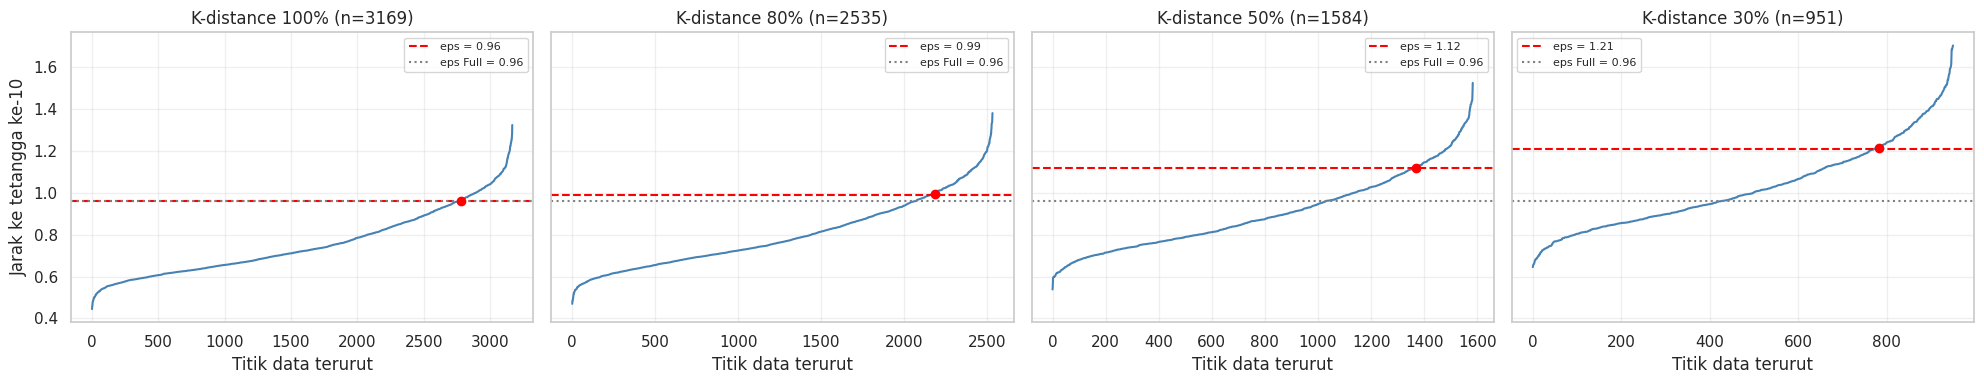

,eps,Jumlah Cluster,Jumlah Noise,Persentase Noise (%),Silhouette Score,Davies-Bouldin,ARI vs Full
Dataset,,,,,,,
100%,0.96,2,27,0.85,0.2085,1.9138,1.0000
80%,0.99,2,35,1.38,0.2085,1.9105,0.9856
50%,1.12,1,20,1.26,NaN,NaN,0.0404
30%,1.21,1,29,3.05,NaN,NaN,0.0974


A: eps tetap                                                                  B: eps per subset                                                                 
                 eps Jumlah Cluster Persentase Noise (%) Silhouette Score ARI vs Full               eps Jumlah Cluster Persentase Noise (%) Silhouette Score ARI vs Full
Dataset                                                                                                                                                                 
100%            0.96              2                 0.85           0.2085      1.0000              0.96              2                 0.85           0.2085      1.0000
80%             0.96              3                 3.16           0.1472      0.9707              0.99              2                 1.38           0.2085      0.9856
50%             0.96              8                14.02           0.0545      0.8628              1.12              1                 1.26              NaN      0.0404
30%             0.96              3                29.65           0.0701      0.7860              1.21              1                 3.05              NaN      0.0974


Suhu per cluster - B, 100%
       count   min   max
label                   
-1        27  18.0  24.9
 0      2214  24.6  33.5
 1       928  18.0  25.0

Suhu per cluster - B, 80%
       count   min   max
label                   
-1        35  18.0  24.8
 0      1776  24.6  33.5
 1       724  18.0  25.0

Suhu per cluster - B, 50%
       count   min   max
label                   
-1        20  18.1  24.8
 0      1564  18.0  33.5

Suhu per cluster - B, 30%
       count   min   max
label                   
-1        29  18.4  24.8
 0       922  18.1  33.5


In [43]:
names = ["100%", "80%", "50%", "30%"]

# 1) K-distance graph per subset + titik siku masing-masing
fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)
eps_B = {}
for ax, name in zip(axes, names):
    kd = kd_all[name]
    i = find_knee(kd)
    eps_B[name] = round(float(kd[i]), 2)
    ax.plot(kd, color="steelblue")
    ax.axhline(eps_B[name], color="red", ls="--", label=f"eps = {eps_B[name]}")
    ax.axhline(EPS, color="gray", ls=":", label=f"eps Full = {EPS}")
    ax.scatter([i], [kd[i]], color="red", zorder=3)
    ax.set_title(f"K-distance {name} (n={len(kd)})")
    ax.set_xlabel("Titik data terurut"); ax.legend(fontsize=8); ax.grid(alpha=.3)
axes[0].set_ylabel(f"Jarak ke tetangga ke-{MIN_SAMPLES}")
plt.tight_layout(); plt.show()

# 2) DBSCAN dengan eps masing-masing (min_samples tetap)
labels_B, rows_B = {}, []
for name in names:
    lab = run_dbscan(scaled[name].values, eps_B[name], MIN_SAMPLES)
    labels_B[name] = pd.Series(lab, index=scaled[name].index)
    ev = evaluate_clustering(scaled[name].values, lab)
    # ARI terhadap label Full Data (pendekatan A, eps Full) pada baris yang sama
    idx = labels_B[name].index
    ari = adjusted_rand_score(labels_dict["100%"].loc[idx], labels_B[name])
    rows_B.append({"Dataset": name, "eps": eps_B[name], **ev, "ARI vs Full": round(ari, 4)})
table_B = pd.DataFrame(rows_B).set_index("Dataset")
display(table_B)

# 3) Tabel gabungan A (parameter tetap) vs B (eps per subset)
A = comparison[["Jumlah Cluster", "Persentase Noise (%)", "Silhouette Score", "ARI vs Full"]].copy()
A.insert(0, "eps", EPS)
B = table_B[["eps", "Jumlah Cluster", "Persentase Noise (%)", "Silhouette Score", "ARI vs Full"]]
gabungan = pd.concat({"A: eps tetap": A, "B: eps per subset": B}, axis=1)
display(gabungan)

# 4) Isi cluster: rentang suhu tiap cluster (untuk menjelaskan MAKNA cluster)
for name in names:
    t = df_clean.loc[labels_B[name].index].assign(label=labels_B[name])
    print(f"\nSuhu per cluster - B, {name}")
    print(t.groupby("label")["Temperature (°C)"].agg(["count", "min", "max"]).round(1))

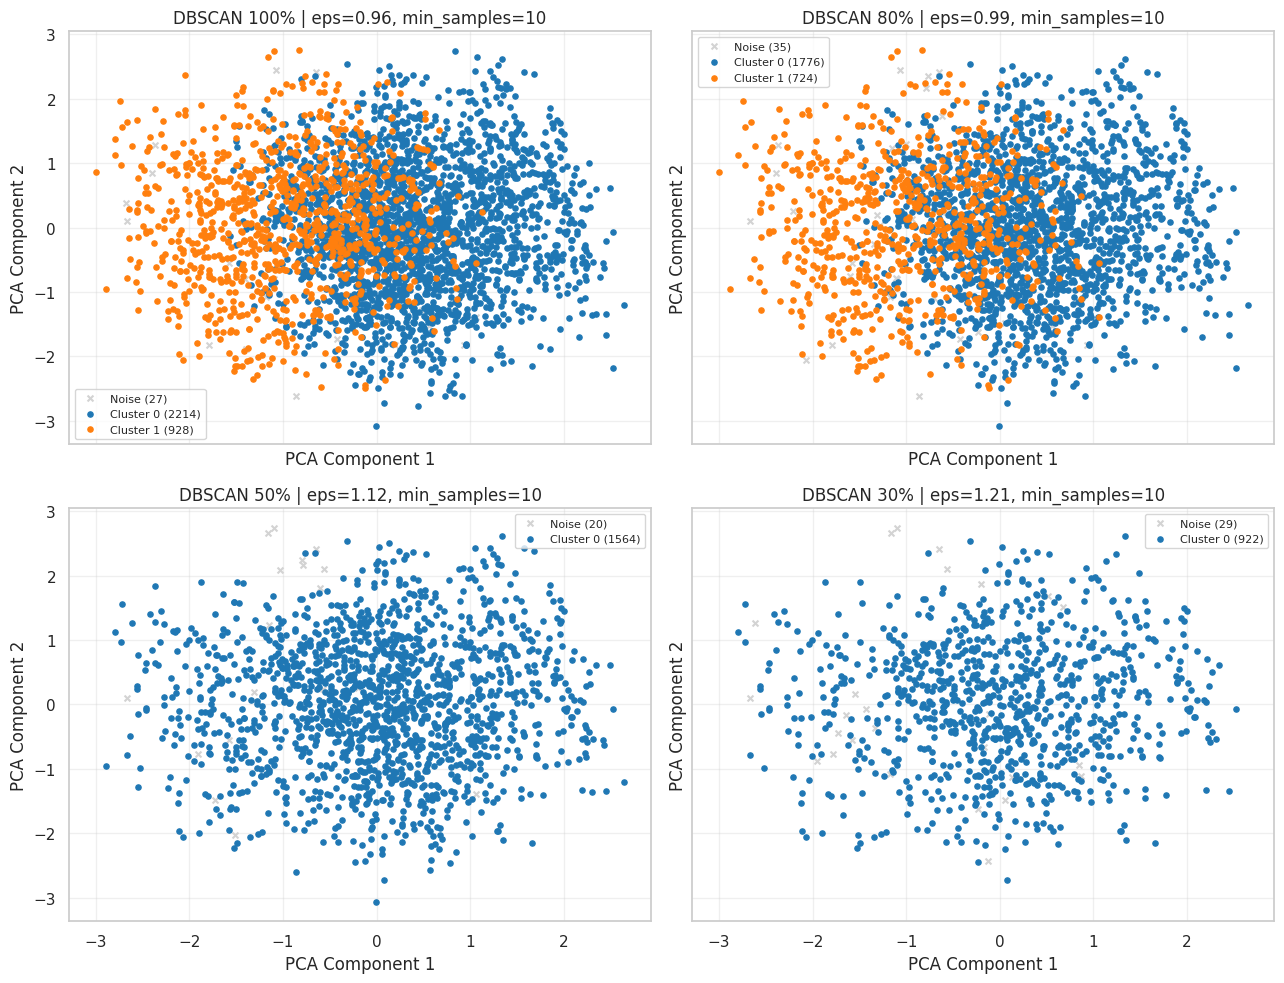

In [44]:
# Visualisasi PCA dengan epsilon masing-masing (Pendekatan B)
fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharex=True, sharey=True)
palette = plt.cm.tab10.colors

for ax, name in zip(axes.ravel(), names):
    P = pca.transform(scaled[name])
    lab = labels_B[name].values
    noise = lab == -1

    # Plot data noise
    ax.scatter(P[noise, 0], P[noise, 1], c="lightgray", marker="x", s=18, label=f"Noise ({noise.sum()})")

    # Plot setiap cluster
    for c in sorted(set(lab) - {-1}):
        m = lab == c
        ax.scatter(P[m, 0], P[m, 1], s=14, color=palette[c % 10], label=f"Cluster {c} ({m.sum()})")

    ax.set_title(f"DBSCAN {name} | eps={eps_B[name]}, min_samples={MIN_SAMPLES}")
    ax.set_xlabel("PCA Component 1")
    ax.set_ylabel("PCA Component 2")
    ax.legend(fontsize=8, loc="best")
    ax.grid(alpha=.3)

plt.tight_layout()
plt.show()

# DBSCAN NON-SAMPLE/BORDER INSTANCE

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Membaca dataset
df = pd.read_csv('lettuce_dataset_updated.csv', encoding='latin1')
df.head()

,Plant_ID,Date,Temperature (°C),Humidity (%),TDS Value (ppm),pH Level,Growth Days,Temperature (F),Humidity
0,1,8/3/2023,33.4,53,582,6.4,1,92.12,0.53
1,1,8/4/2023,33.5,53,451,6.1,2,92.30,0.53
2,1,8/5/2023,33.4,59,678,6.4,3,92.12,0.59
3,1,8/6/2023,33.4,68,420,6.4,4,92.12,0.68
4,1,8/7/2023,33.4,74,637,6.5,5,92.12,0.74


In [46]:
import pandas as pd
print("Ukuran Dataset:", df.shape)
print("\nNama Kolom:", df.columns.tolist())
print("\nInformasi Dataset:")
df.info()
print("\nJumlah Missing Value:")
print(df.isnull().sum())

Ukuran Dataset: (3169, 9)

Nama Kolom: ['Plant_ID', 'Date', 'Temperature (°C)', 'Humidity (%)', 'TDS Value (ppm)', 'pH Level', 'Growth Days', 'Temperature (F)', 'Humidity']

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3169 entries, 0 to 3168
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Plant_ID          3169 non-null   int64  
 1   Date              3169 non-null   object 
 2   Temperature (°C)  3169 non-null   float64
 3   Humidity (%)      3169 non-null   int64  
 4   TDS Value (ppm)   3169 non-null   int64  
 5   pH Level          3169 non-null   float64
 6   Growth Days       3169 non-null   int64  
 7   Temperature (F)   3169 non-null   float64
 8   Humidity          3169 non-null   float64
dtypes: float64(4), int64(4), object(1)
memory usage: 222.9+ KB

Jumlah Missing Value:
Plant_ID            0
Date                0
Temperature (°C)    0
Humidity (%)        0
TDS Value

In [47]:
features = ['Temperature (°C)', 'Humidity (%)', 'TDS Value (ppm)', 'pH Level', 'Growth Days']
X_raw = df[features].copy()
print("Fitur yang digunakan untuk clustering:")
display(X_raw.head())

Fitur yang digunakan untuk clustering:


,Temperature (°C),Humidity (%),TDS Value (ppm),pH Level,Growth Days
0,33.4,53,582,6.4,1
1,33.5,53,451,6.1,2
2,33.4,59,678,6.4,3
3,33.4,68,420,6.4,4
4,33.4,74,637,6.5,5


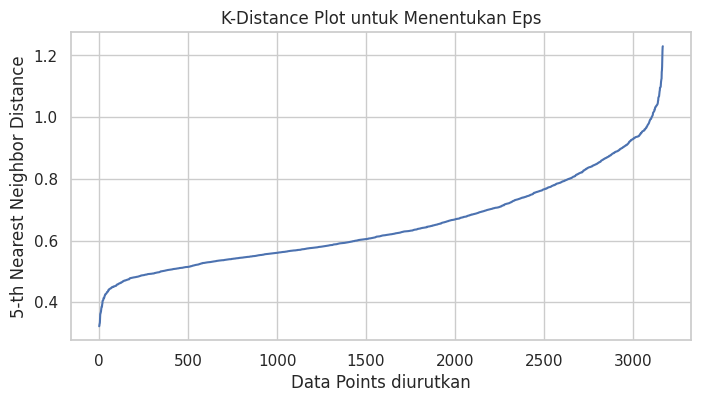

In [48]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# Standardisasi fitur
scaler = StandardScaler()
X_scaled_full = scaler.fit_transform(X_raw)

# Menggunakan min_samples = 6
min_samples_val = 6

neighbors = NearestNeighbors(n_neighbors=min_samples_val)
neighbors_fit = neighbors.fit(X_scaled_full)
distances, indices = neighbors_fit.kneighbors(X_scaled_full)

# Urutkan jarak terdekat
distances = np.sort(distances[:, min_samples_val-1], axis=0)

plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.title("K-Distance Plot untuk Menentukan Eps")
plt.xlabel("Data Points diurutkan")
plt.ylabel(f"{min_samples_val-1}-th Nearest Neighbor Distance")
plt.grid(True)
plt.show()

In [49]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

eps_val = 1.0
min_samples_val = 6

def analyze_dbscan(data_fraction, fraction_name, full_df, features, eps, min_samples):
    # Sampling
    if data_fraction < 1.0:
        df_sub = full_df.sample(frac=data_fraction, random_state=42).copy()
    else:
        df_sub = full_df.copy()

    # Preprocessing
    X_sub = df_sub[features]
    scaler_sub = StandardScaler()
    X_scaled = scaler_sub.fit_transform(X_sub)

    # DBSCAN Fit
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)
    labels = db.labels_

    # Cari Core Samples indices
    core_samples_mask = np.zeros_like(labels, dtype=bool)
    core_samples_mask[db.core_sample_indices_] = True

    # Klasifikasikan setiap baris
    type_labels = []
    for idx in range(len(labels)):
        if core_samples_mask[idx]:
            type_labels.append('Core')
        elif labels[idx] != -1:
            type_labels.append('Border')
        else:
            type_labels.append('Noise')

    df_sub['DBSCAN_Type'] = type_labels
    df_sub['Cluster_Label'] = labels

    # Hitung jumlah masing-masing tipe
    num_core = sum(df_sub['DBSCAN_Type'] == 'Core')
    num_border = sum(df_sub['DBSCAN_Type'] == 'Border')
    num_noise = sum(df_sub['DBSCAN_Type'] == 'Noise')
    pct_border = (num_border / len(df_sub)) * 100

    summary = {
        'Dataset': fraction_name,
        'Jumlah Data': len(df_sub),
        'Core Sample': num_core,
        'Border Instance': num_border,
        'Noise': num_noise,
        '% Border': f"{pct_border:.2f}%"
    }

    return df_sub, X_scaled, summary

# Jalankan keempat skenario
results = {}
summaries = []

for frac, name in zip([1.0, 0.8, 0.5, 0.3], ['100% (Full)', '80% Data', '50% Data', '30% Data']):
    df_res, X_sc, sum_res = analyze_dbscan(frac, name, df, features, eps_val, min_samples_val)
    results[name] = (df_res, X_sc)
    summaries.append(sum_res)

In [50]:
import pandas as pd
df_summary = pd.DataFrame(summaries)
display(df_summary)

,Dataset,Jumlah Data,Core Sample,Border Instance,Noise,% Border
0,100% (Full),3169,3106,63,0,1.99%
1,80% Data,2535,2440,93,2,3.67%
2,50% Data,1584,1406,149,29,9.41%
3,30% Data,951,713,147,91,15.46%


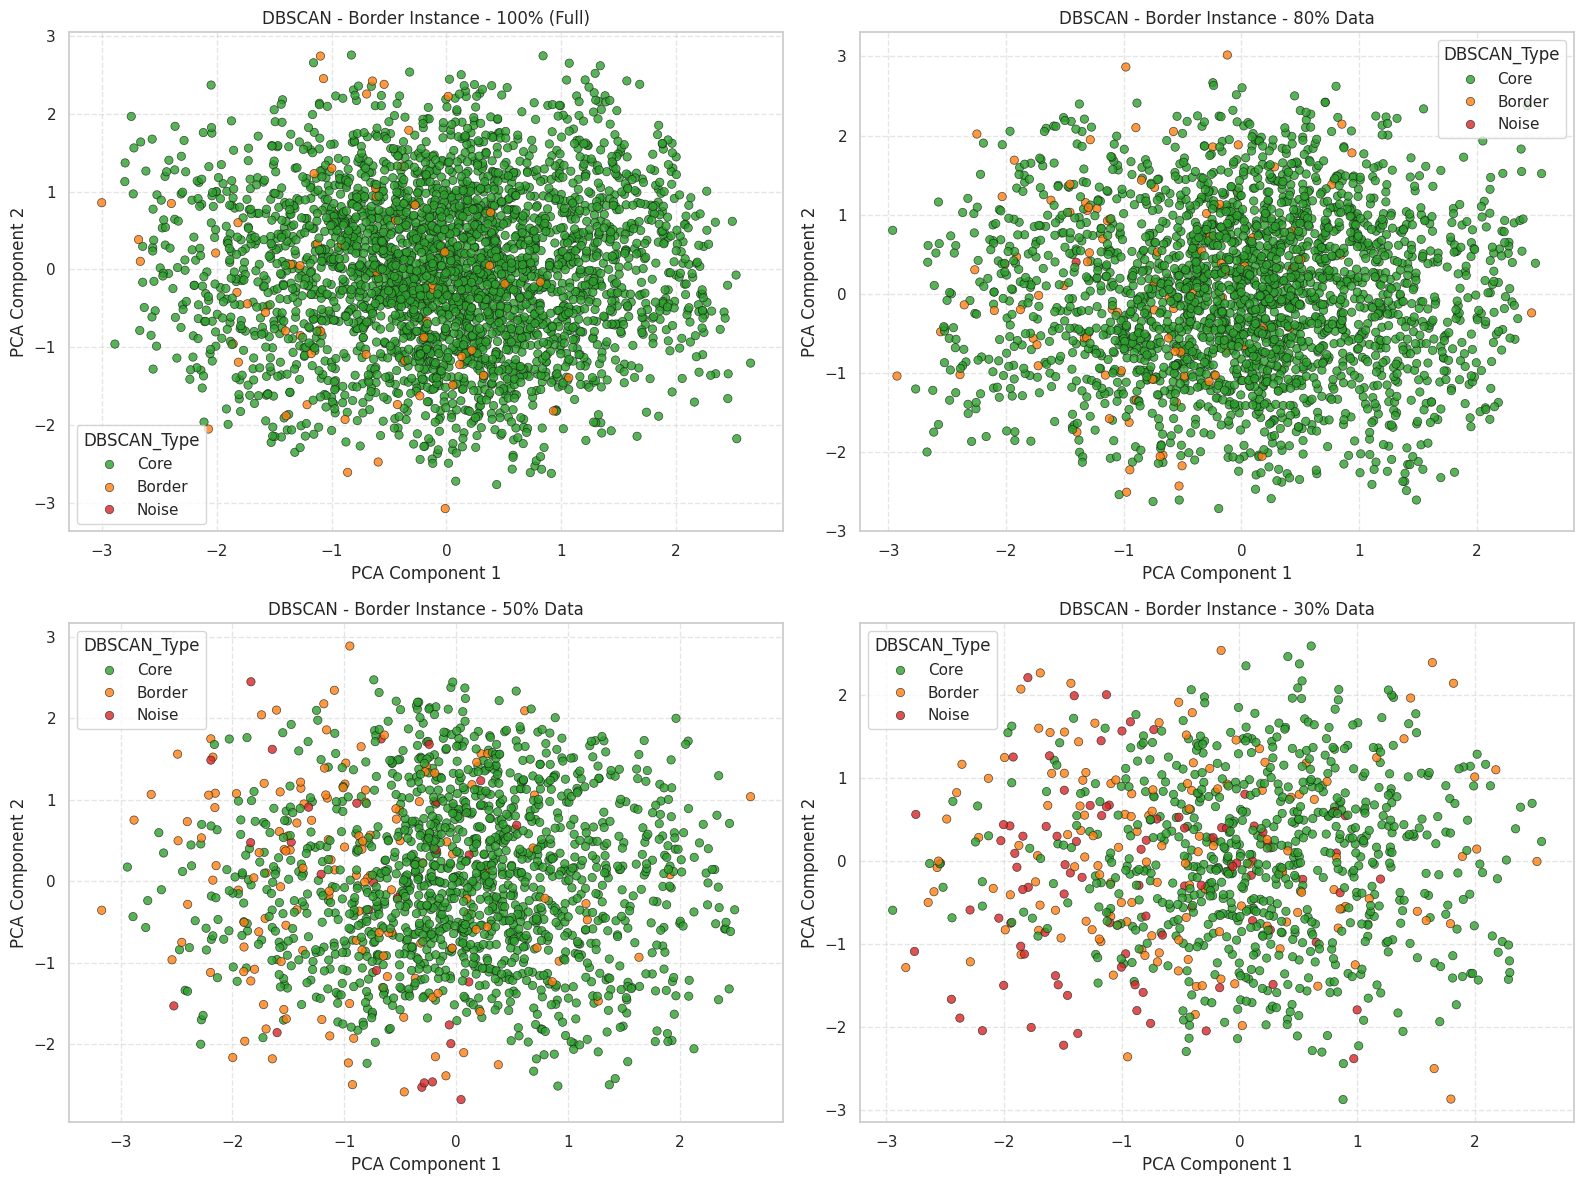

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, name in enumerate(['100% (Full)', '80% Data', '50% Data', '30% Data']):
    df_res, X_sc = results[name]

    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_sc)

    df_plot = df_res.copy()
    df_plot['PCA1'] = X_pca[:, 0]
    df_plot['PCA2'] = X_pca[:, 1]

    sns.scatterplot(
        x='PCA1', y='PCA2', hue='DBSCAN_Type',
        hue_order=['Core', 'Border', 'Noise'],
        palette={'Core': '#2ca02c', 'Border': '#ff7f0e', 'Noise': '#d62728'},
        data=df_plot, ax=axes[i], alpha=0.8, edgecolor='k'
    )
    axes[i].set_title(f"DBSCAN - Border Instance - {name}")
    axes[i].set_xlabel("PCA Component 1")
    axes[i].set_ylabel("PCA Component 2")
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [52]:
for name in ['100% (Full)', '80% Data', '50% Data', '30% Data']:
    df_res, _ = results[name]
    border_df = df_res[df_res['DBSCAN_Type'] == 'Border']
    print(f"=== Border Instance - {name} (Total: {len(border_df)}) ===")
    display(border_df.head(5))

=== Border Instance - 100% (Full) (Total: 63) ===


,Plant_ID,Date,Temperature (°C),Humidity (%),TDS Value (ppm),pH Level,Growth Days,Temperature (F),Humidity,DBSCAN_Type,Cluster_Label
1091,24,9/16/2023,25.0,62,490,6.1,45,77.00,0.62,Border,0
1639,37,8/10/2023,22.7,50,784,6.3,8,72.86,0.50,Border,0
2074,46,9/9/2023,20.1,80,501,6.0,38,68.18,0.80,Border,0
2216,49,9/14/2023,29.1,79,417,6.8,43,84.38,0.79,Border,0
2320,52,8/14/2023,24.9,70,797,6.0,12,76.82,0.70,Border,0


=== Border Instance - 80% Data (Total: 93) ===


,Plant_ID,Date,Temperature (°C),Humidity (%),TDS Value (ppm),pH Level,Growth Days,Temperature (F),Humidity,DBSCAN_Type,Cluster_Label
2880,64,8/30/2023,24.8,78,753,6.4,28,76.64,0.78,Border,0
2626,58,9/15/2023,24.7,63,760,6.6,44,76.46,0.63,Border,0
2515,56,8/26/2023,22.0,67,735,6.0,24,71.60,0.67,Border,0
2878,64,8/28/2023,18.5,80,410,6.5,26,65.30,0.80,Border,0
2763,62,8/3/2023,19.3,61,483,6.7,1,66.74,0.61,Border,0


=== Border Instance - 50% Data (Total: 149) ===


,Plant_ID,Date,Temperature (°C),Humidity (%),TDS Value (ppm),pH Level,Growth Days,Temperature (F),Humidity,DBSCAN_Type,Cluster_Label
3162,70,9/11/2023,21.2,66,500,6.8,40,70.16,0.66,Border,0
3123,70,8/3/2023,24.7,65,752,6.3,1,76.46,0.65,Border,0
194,5,8/12/2023,30.2,77,417,6.8,10,86.36,0.77,Border,0
2925,65,8/30/2023,24.9,54,463,6.3,28,76.82,0.54,Border,0
3086,69,8/11/2023,20.3,69,793,6.4,9,68.54,0.69,Border,0


=== Border Instance - 30% Data (Total: 147) ===


,Plant_ID,Date,Temperature (°C),Humidity (%),TDS Value (ppm),pH Level,Growth Days,Temperature (F),Humidity,DBSCAN_Type,Cluster_Label
194,5,8/12/2023,30.2,77,417,6.8,10,86.36,0.77,Border,0
3086,69,8/11/2023,20.3,69,793,6.4,9,68.54,0.69,Border,1
495,11,9/9/2023,20.1,50,662,6.0,38,68.18,0.50,Border,1
874,20,8/11/2023,31.9,50,592,6.6,9,89.42,0.50,Border,0
2984,66,9/13/2023,21.8,77,601,6.3,42,71.24,0.77,Border,1


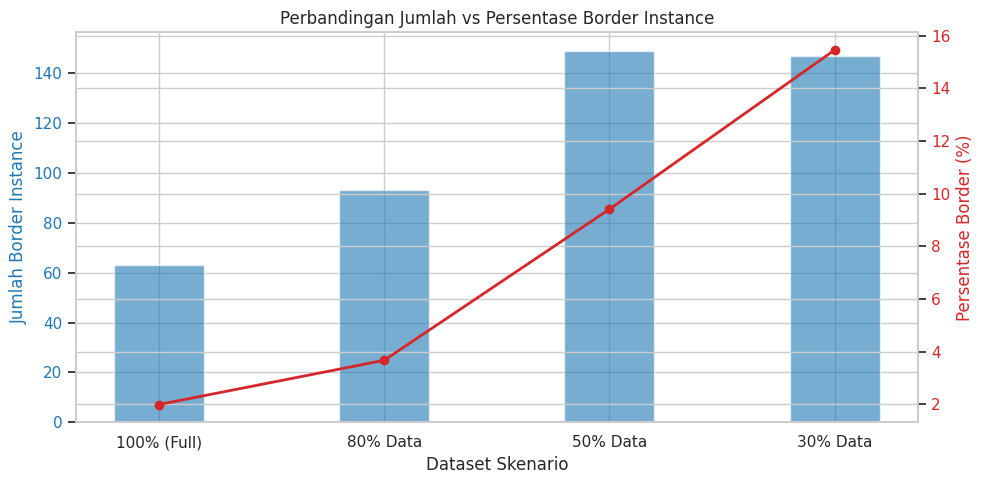

In [53]:
import matplotlib.pyplot as plt

df_summary['% Border_float'] = df_summary['% Border'].str.rstrip('%').astype(float)

fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Dataset Skenario')
ax1.set_ylabel('Jumlah Border Instance', color=color)
ax1.bar(df_summary['Dataset'], df_summary['Border Instance'], color=color, alpha=0.6, width=0.4, label='Jumlah Border')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Persentase Border (%)', color=color)
ax2.plot(df_summary['Dataset'], df_summary['% Border_float'], color=color, marker='o', linewidth=2, label='Persentase Border')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Perbandingan Jumlah vs Persentase Border Instance')
fig.tight_layout()
plt.show()

# DBSCAN OUTLIER/NOISER/ANOMALI

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.read_csv('lettuce_dataset_updated.csv', encoding = "latin1")

df.head()

,Plant_ID,Date,Temperature (°C),Humidity (%),TDS Value (ppm),pH Level,Growth Days,Temperature (F),Humidity
0,1,8/3/2023,33.4,53,582,6.4,1,92.12,0.53
1,1,8/4/2023,33.5,53,451,6.1,2,92.30,0.53
2,1,8/5/2023,33.4,59,678,6.4,3,92.12,0.59
3,1,8/6/2023,33.4,68,420,6.4,4,92.12,0.68
4,1,8/7/2023,33.4,74,637,6.5,5,92.12,0.74


In [55]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# 1. Definisikan Fitur & Normalisasi Data Full (100%)
dbscan_features = ['Temperature (°C)', 'Humidity (%)', 'TDS Value (ppm)', 'pH Level', 'Growth Days']
X_scaled_full = StandardScaler().fit_transform(df[dbscan_features])

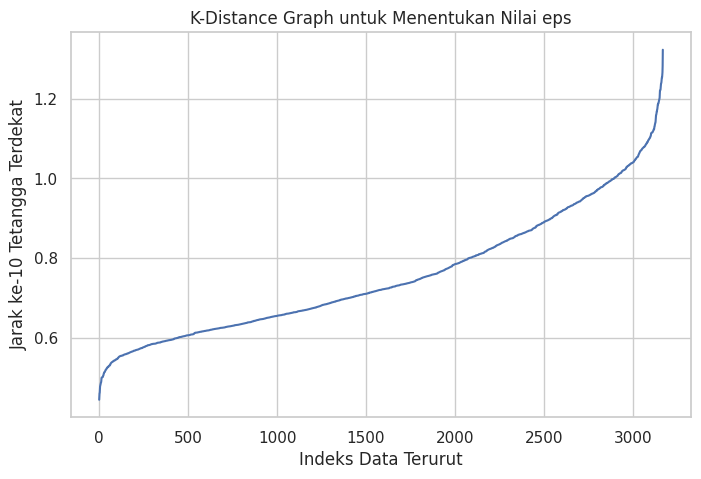

In [56]:
# 2. K-Distance Graph
min_samples = 10
nn = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled_full)
distances, _ = nn.kneighbors(X_scaled_full)
k_distances = np.sort(distances[:, min_samples - 1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.xlabel('Indeks Data Terurut')
plt.ylabel(f'Jarak ke-{min_samples} Tetangga Terdekat')
plt.title('K-Distance Graph untuk Menentukan Nilai eps')
plt.grid(True)
plt.show()

### **eps = 1.35**
Nilai eps didapat dari K-distance graph

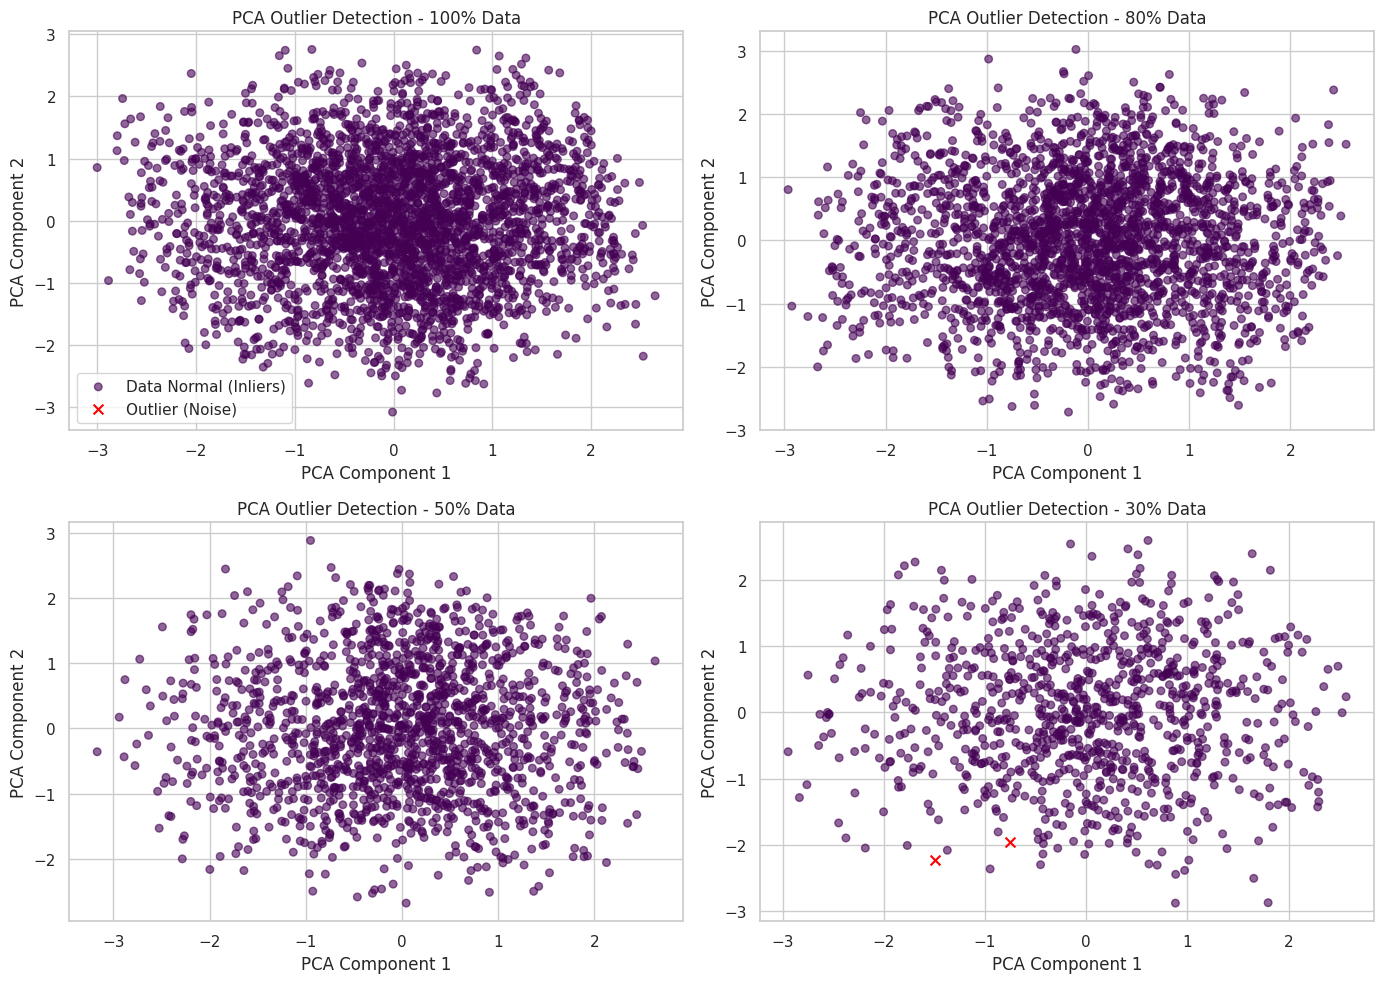

In [57]:
# 3. Evaluasi DBSCAN, Simpan Hasil Tabel, & Visualisasi Outlier PCA
percentages = [1.0, 0.8, 0.5, 0.3]
eps_val = 1.35
tabel_hasil = []
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, p in enumerate(percentages):
    # Sampling data sesuai proporsi
    df_sub = df if p == 1.0 else df.sample(frac=p, random_state=42).copy()
    X_sub_scaled = StandardScaler().fit_transform(df_sub[dbscan_features])

    # Fit DBSCAN & Prediksi Cluster
    dbscan = DBSCAN(eps=eps_val, min_samples=min_samples)
    clusters = dbscan.fit_predict(X_sub_scaled)

    # Hitung Titik Bising
    n_noise = (clusters == -1).sum()
    total = len(df_sub)
    persentase_noise = (n_noise / total) * 100

    # Simpan hasil iterasi saat ini ke dalam list tabel_hasil
    tabel_hasil.append({
        'Proporsi Data': f"{int(p*100)}%",
        'Total Data': total,
        'Nilai eps': eps_val,
        'Titik Bising (Noise)': n_noise,
        'Persentase Noise (%)': f"{persentase_noise:.2f}%"
    })

    # Visualisasi PCA
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_sub_scaled)

    outliers = clusters == -1
    inliers = clusters != -1

    axes[idx].scatter(X_pca[inliers, 0], X_pca[inliers, 1], c=clusters[inliers], cmap='viridis', s=30, alpha=0.6, label='Data Normal (Inliers)')
    axes[idx].scatter(X_pca[outliers, 0], X_pca[outliers, 1], color='red', marker='x', s=50, label='Outlier (Noise)')

    axes[idx].set_title(f'PCA Outlier Detection - {int(p*100)}% Data')
    axes[idx].set_xlabel('PCA Component 1')
    axes[idx].set_ylabel('PCA Component 2')

    if idx == 0:
        axes[idx].legend()

# Tampilkan scatter plot
plt.tight_layout()
plt.show()

In [58]:
print("\nTabel Perbandingan Hasil Deteksi Outlier (DBSCAN)")
df_hasil_dbscan = pd.DataFrame(tabel_hasil)

display(df_hasil_dbscan)


Tabel Perbandingan Hasil Deteksi Outlier (DBSCAN)


,Proporsi Data,Total Data,Nilai eps,Titik Bising (Noise),Persentase Noise (%)
0,100%,3169,1.35,0,0.00%
1,80%,2535,1.35,0,0.00%
2,50%,1584,1.35,0,0.00%
3,30%,951,1.35,2,0.21%


# Evaluasi Akhir Metode
Berdasarkan metrik evaluasi yang diperoleh, Cosine Similarity adalah metode yang paling bagus (best) untuk dataset ini. Karena skor silhouette nya tertinggi dan paling stabil, secara konsisten di rentang 0.26 sampai 0.30 pada berbagai proporsi data. Jika dibandingkan sama Euclidean dan Manhattan, nilai Cosine jauh lebih tinggi. Hasil ketiga metode:<br><br>
Hasil Evaluasi Euclidean Distance (k= 4)<br>
Full Data (100%)     | Silhouette Score: 0.1547 | Inertia: 10258.11<br>
80% Data             | Silhouette Score: 0.1527 | Inertia: 8538.81<br>
50% Data             | Silhouette Score: 0.1576 | Inertia: 5143.96<br>
30% Data             | Silhouette Score: 0.1775 | Inertia: 3144.81
<br><br>
Hasil Evaluasi Manhattan Distance (k= 6)<br>
Full Data (100%)     | Silhouette Score: 0.1518 | Absolute Error: 9123.38<br>
80% Data             | Silhouette Score: 0.1621 | Absolute Error: 7324.62<br>
50% Data             | Silhouette Score: 0.1630 | Absolute Error: 4588.92<br>
30% Data             | Silhouette Score: 0.1672 | Absolute Error: 2693.73
<br><br>
Hasil Evaluasi Cosine Distance (k=4)<br>
Full Data (100%)     | Silhouette Score: 0.2993 | Inertia: 1234.27<br>
80% Data             | Silhouette Score: 0.2711 | Inertia: 1054.12<br>
50% Data             | Silhouette Score: 0.2635 | Inertia: 661.74<br>
30% Data             | Silhouette Score: 0.3005 | Inertia: 371.08